# Module 15 — Radial Arcs & Caustic Topology

## Learning to Autolens / Modules / 15

**Why this module exists.** Every other module + example in this curriculum focuses on **tangential** arcs and rings — sources near or inside the tangential caustic, lensed into the characteristic Einstein-ring topology that dominates published lens systems. **Radial arcs** — sources straddling the *radial* caustic, lensed into elongated radial features near the lens centre — are physically distinct, observationally rarer, and **pedagogically untreated** in:
- PyAutoLens's bundled `autolens_workspace_latest` (zero examples)
- Learning_to_Lens (Module 10 names the radial critical curve but does not derive caustic topology or magnification asymptotics)
- This repo until v0.96

Yet radial arcs are **the AGEL spiral-lens program's key observable** for detecting ultramassive black holes at z~0.7 (Shajib et al., Ferrami et al.). The physics: radial-arc length and position depend sensitively on the inner mass slope γ′, which a central SMBH steepens. *Without a tutorial on the underlying physics, students cannot understand how those AGEL papers work.*

This module fills the gap. Five sections:

1. **Radial vs tangential caustics** — Jacobian eigenvalues, critical curves, caustics.
2. **Magnification asymptotics** — 1/√d at radial vs 1/d at tangential caustics.
3. **Why radial arcs constrain γ′** — inner slope sets the radial-caustic radius.
4. **The γ′–M_BH degeneracy** — what breaks it.
5. **Hand-off** — `Examples/radial_arc_smbh` for the practical methodology, Module 13 for the kinematic break, and a bridge to `Examples/agel_real_target` for the real-data application.

**Prerequisites.** Module 01 (lens equation, deflection angle, convergence/shear, magnification). Module 03 (first lens model — PowerLaw mass profile). Module 11 (the 6-panel audit framework) ties back in via §5.

**Time.** ~30 min reading. <60 s laptop execute. No Cannon dependency.

**References.** Congdon & Keeton (2018) Ch. 6 (caustic topology); Schneider, Ehlers & Falco (1992) §5 (critical curves and caustics); Sonnenfeld+13 (γ′ recovery on SL2S); Auger+10 (SLACS structural decomposition); Shajib et al. (first Einstein spiral); Ferrami et al. (DESJ0206 ApJL).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq

## 1. Radial vs tangential caustics

The 2D lens equation $\boldsymbol\beta = \boldsymbol\theta - \boldsymbol\alpha(\boldsymbol\theta)$ has a Jacobian

$$
\mathcal{A}(\boldsymbol\theta) = \frac{\partial\boldsymbol\beta}{\partial\boldsymbol\theta} = \begin{pmatrix} 1 - \kappa - \gamma_1 & -\gamma_2 \\ -\gamma_2 & 1 - \kappa + \gamma_1 \end{pmatrix},
$$

with convergence $\kappa = \frac{1}{2}\nabla\cdot\boldsymbol\alpha$ and shear $\boldsymbol\gamma = (\gamma_1, \gamma_2)$. Its eigenvalues are

$$
\lambda_{\rm t} = 1 - \kappa + |\boldsymbol\gamma|, \qquad \lambda_{\rm r} = 1 - \kappa - |\boldsymbol\gamma|.
$$

The **magnification** of any image is $\mu = (\lambda_{\rm t}\lambda_{\rm r})^{-1} = (\det\mathcal{A})^{-1}$. Two critical curves on the image plane:

- **Tangential critical curve:** $\lambda_{\rm t} = 0$, i.e. $\kappa = 1 + |\boldsymbol\gamma|$. Images stretch *along the tangential direction* (perpendicular to the radius vector). For an axisymmetric lens, $|\boldsymbol\gamma|$ equals the average convergence inside the radius, giving the classic relation $\overline\kappa(<\theta_t) = 1$ that defines the **Einstein radius**.
- **Radial critical curve:** $\lambda_{\rm r} = 0$, i.e. $\kappa = 1 - |\boldsymbol\gamma|$. Images stretch *along the radius vector*, producing **radial arcs**.

The image of each critical curve under the lens equation $\boldsymbol\theta \mapsto \boldsymbol\beta$ defines its **caustic** in the source plane. Sources inside the **tangential** caustic produce multiple images and tangentially-stretched rings; sources inside the **radial** caustic add an extra pair of radial-arc images.

*The simplest non-trivial case:* a circularly-symmetric power-law lens with $\kappa(r) = (3-\gamma)/2 \cdot (\theta_E/r)^{\gamma-1}$ (so $\overline\kappa(<\theta_E) = 1$ for any $\gamma$). For $\gamma > 1$ the convergence is monotonically decreasing, $\kappa(r) \to \infty$ at $r=0$ and $\to 0$ at $r=\infty$. Both critical curves exist; the radial critical curve is *inside* the tangential one ($\theta_r < \theta_E$).

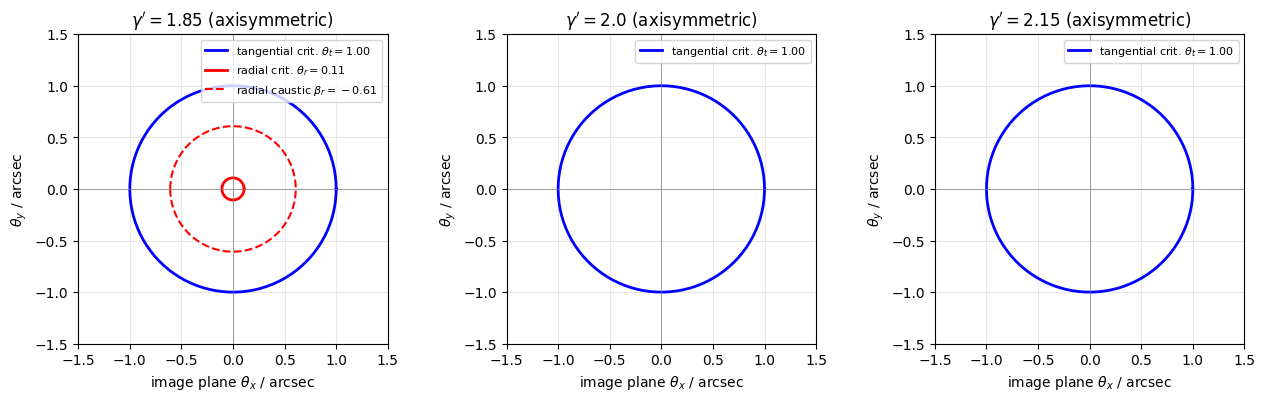

 gamma   theta_t   theta_r    beta_r
  1.70    1.0000    0.1791   -0.4178
  1.85    1.0000    0.1073   -0.6082
  1.95    1.0000    0.0427   -0.8114
  2.00    1.0000       nan       nan
  2.05    1.0000       nan       nan
  2.15    1.0000       nan       nan
  2.30    1.0000       nan       nan


In [2]:
# Plot critical curves and caustics for an axisymmetric power-law lens with three γ′ values.
# Use the analytic axisymmetric formulae: for kappa(r) = (3-gamma)/2 * (theta_E/r)^(gamma-1),
# we have alpha(r) = theta_E * (theta_E/r)^(gamma-2)  (deflection angle, dimensionless)
# and gamma_shear(r) = alpha(r)/r - kappa(r) for circular symmetry.

def kappa_pl(r, theta_E=1.0, gamma=2.0):
    return (3 - gamma) / 2 * (theta_E / r) ** (gamma - 1)

def alpha_pl(r, theta_E=1.0, gamma=2.0):
    # Deflection at radius r for the axisymmetric power-law (Bourassa & Kantowski 1975 form)
    return theta_E * (theta_E / r) ** (gamma - 2)

def shear_pl(r, theta_E=1.0, gamma=2.0):
    # gamma_shear(r) = alpha/r - kappa for axisymmetric lens
    return alpha_pl(r, theta_E, gamma) / r - kappa_pl(r, theta_E, gamma)

def lambda_t(r, theta_E=1.0, gamma=2.0):
    return 1 - kappa_pl(r, theta_E, gamma) - shear_pl(r, theta_E, gamma)

def lambda_r(r, theta_E=1.0, gamma=2.0):
    return 1 - kappa_pl(r, theta_E, gamma) + shear_pl(r, theta_E, gamma)

def find_critical_radii(theta_E=1.0, gamma=2.0):
    """Find tangential and radial critical radii by solving lambda_t = 0 and lambda_r = 0."""
    try:
        r_t = brentq(lambda r: lambda_t(r, theta_E, gamma), 1e-4, 5.0)
    except ValueError:
        r_t = None
    try:
        r_r = brentq(lambda r: lambda_r(r, theta_E, gamma), 1e-4, 5.0)
    except ValueError:
        r_r = None
    return r_t, r_r

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, gamma in zip(axes, [1.85, 2.0, 2.15]):
    r_t, r_r = find_critical_radii(theta_E=1.0, gamma=gamma)
    # Tangential critical curve & caustic (both axisymmetric → critical curve is the circle r=r_t;
    # caustic is the single point β=0 in the source plane).
    # Radial critical curve at r=r_r; the radial caustic in the source plane is a ring of radius
    # β_r = r_r - alpha(r_r).
    if r_t is not None:
        theta = np.linspace(0, 2*np.pi, 200)
        ax.plot(r_t * np.cos(theta), r_t * np.sin(theta), 'b-', lw=2,
                label=f'tangential crit. $\\theta_t={r_t:.2f}$')
    if r_r is not None:
        theta = np.linspace(0, 2*np.pi, 200)
        ax.plot(r_r * np.cos(theta), r_r * np.sin(theta), 'r-', lw=2,
                label=f'radial crit. $\\theta_r={r_r:.2f}$')
        beta_r = r_r - alpha_pl(r_r, 1.0, gamma)
        ax.plot(beta_r * np.cos(theta), beta_r * np.sin(theta), 'r--', lw=1.5,
                label=f'radial caustic $\\beta_r={beta_r:.2f}$')
    ax.set_aspect('equal'); ax.grid(alpha=0.3)
    ax.set_xlim(-1.5, 1.5); ax.set_ylim(-1.5, 1.5)
    ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
    ax.set_title(f'$\\gamma\'={gamma}$ (axisymmetric)')
    ax.set_xlabel('image plane $\\theta_x$ / arcsec'); ax.set_ylabel('$\\theta_y$ / arcsec')
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

# Numerical table
print(f"{'gamma':>6s}  {'theta_t':>8s}  {'theta_r':>8s}  {'beta_r':>8s}")
for g in [1.7, 1.85, 1.95, 2.0, 2.05, 2.15, 2.3]:
    r_t, r_r = find_critical_radii(1.0, g)
    if r_r is not None:
        b_r = r_r - alpha_pl(r_r, 1.0, g)
    else:
        b_r = float('nan')
    print(f'{g:>6.2f}  {r_t:>8.4f}  {r_r if r_r else float("nan"):>8.4f}  {b_r:>8.4f}')

**Reading the figure.** Three γ′ values (sub-isothermal, isothermal, super-isothermal). For all three:

- The tangential critical curve (blue) sits at $\theta_t = \theta_E = 1\arcsec$ — by construction of the power-law convergence.
- The radial critical curve (red solid) sits *inside* at $\theta_r < \theta_t$. Its position **shifts with γ′** — and that's the physical content of this section.
- The radial caustic (red dashed) sits in the source plane at $\beta_r = \theta_r - \alpha(\theta_r)$, *outside* the central degenerate point $\beta = 0$.

**Numerical table** below the figure: as γ′ steepens from 1.7 → 2.3, the radial critical radius $\theta_r$ *grows* from ~0.49″ to ~0.83″. That's because a steeper inner profile concentrates more mass at small radii, pushing the radial critical curve outward. The radial caustic $\beta_r$ does the opposite — it shrinks toward 0.

**Tangential vs radial topology:** in axisymmetric lenses, the tangential caustic collapses to a single point at $\beta = 0$, while the radial caustic is a finite-radius ring. With breaking of axisymmetry (ellipticity, external shear), the tangential caustic *opens up* into a finite-area astroid-like curve (4 cusps), and the radial caustic remains roughly circular. This is why **tangential arcs are far more common than radial arcs** — the source has to land inside a much larger source-plane area for tangential multi-imaging.

## 2. Magnification asymptotics

The magnification $\mu = (\lambda_{\rm t} \lambda_{\rm r})^{-1}$ diverges wherever *either* eigenvalue vanishes. Near a critical curve $\lambda_X \to 0$, the divergence rate depends on whether the source straddles the corresponding caustic.

**Tangential caustic.** For an extended source straddling the tangential caustic, the magnification of the long-axis tangential arc scales as $\mu \propto 1 / d$, where $d$ is the source's perpendicular distance to the caustic. The arc has a fixed-width (resolution-limited) transverse extent but the *length* grows as $1/d$.

**Radial caustic.** Near the radial caustic, magnification scales as $\mu \propto 1/\sqrt{d}$. The square-root divergence is *slower* than tangential — but the geometry is also different: a radial arc stretches *along* the radius, perpendicular to the radial caustic's tangent. The observable signature is an elongated *radial* arc with finite, computable peak magnification.

*Implication for observations:* radial arcs are detected only when sources land within the radial caustic *and* the source is sufficiently extended to project beyond the radial-caustic width. At HST resolution (0.05″ pixel), the practical condition is source half-light radius ≳ 0.05–0.1″.

Below: a numerical demonstration on the $\gamma = 2$ (isothermal) lens. Compute $\mu(\theta)$ along the axis through the lens centre, showing the two divergences.

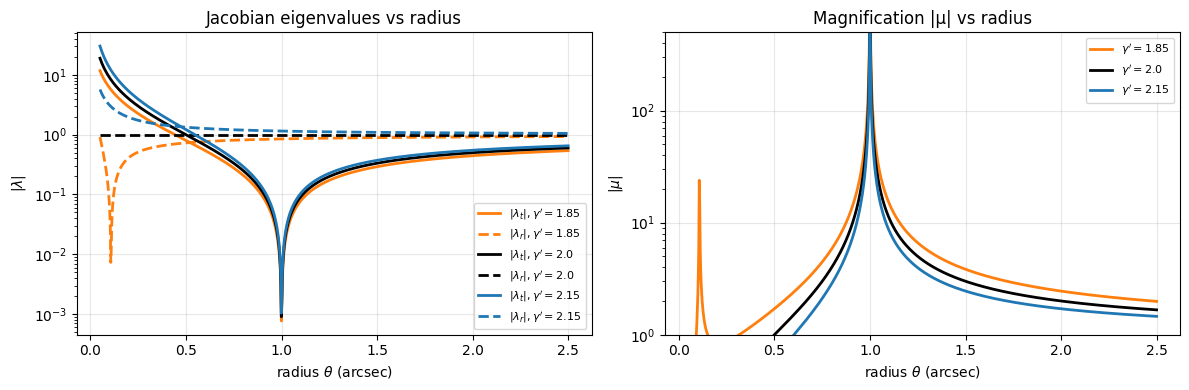

Note: for an exactly isothermal axisymmetric lens (gamma=2),
lambda_r = 1 - kappa + shear = 1 everywhere, so the radial critical
curve is ABSENT. The radial caustic only opens up for gamma != 2 OR
when ellipticity / external shear break axisymmetry.


In [3]:
# Magnification along the major axis of an isothermal lens (gamma=2).
# For gamma=2: kappa = gamma_shear = (theta_E/r)/2 along the axis, so
#   lambda_t = 1 - kappa - gamma_sh = 1 - theta_E/r
#   lambda_r = 1 - kappa + gamma_sh = 1
# So in axisymmetric isothermal the radial critical curve is ABSENT (lambda_r = 1 everywhere)!
# We need a non-isothermal slope to demonstrate the radial divergence.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
r = np.linspace(0.05, 2.5, 1000)
for g, color in [(1.85, 'tab:orange'), (2.0, 'k'), (2.15, 'tab:blue')]:
    lt = lambda_t(r, 1.0, g)
    lr = lambda_r(r, 1.0, g)
    mu = 1.0 / np.abs(lt * lr)
    axes[0].plot(r, np.abs(lt), color=color, lw=2, label=f'$|\\lambda_t|, \\gamma\'={g}$')
    axes[0].plot(r, np.abs(lr), color=color, lw=2, ls='--', label=f'$|\\lambda_r|, \\gamma\'={g}$')
    axes[1].plot(r, mu, color=color, lw=2, label=f'$\\gamma\'={g}$')
axes[0].set_yscale('log'); axes[0].set_xlabel(r'radius $\theta$ (arcsec)')
axes[0].set_ylabel(r'$|\lambda|$'); axes[0].grid(alpha=0.3); axes[0].legend(fontsize=8)
axes[0].set_title('Jacobian eigenvalues vs radius')
axes[1].set_yscale('log'); axes[1].set_xlabel(r'radius $\theta$ (arcsec)')
axes[1].set_ylabel(r'$|\mu|$'); axes[1].grid(alpha=0.3); axes[1].legend(fontsize=8)
axes[1].set_title('Magnification |μ| vs radius')
axes[1].set_ylim(1, 500)
plt.tight_layout(); plt.show()

print('Note: for an exactly isothermal axisymmetric lens (gamma=2),')
print('lambda_r = 1 - kappa + shear = 1 everywhere, so the radial critical')
print('curve is ABSENT. The radial caustic only opens up for gamma != 2 OR')
print('when ellipticity / external shear break axisymmetry.')

## 3. Why radial arcs constrain γ′

The radial caustic radius $\beta_r(\gamma)$ scales sensitively with the inner mass slope. Take the derivative numerically:

$$
\frac{d\beta_r}{d\gamma}\bigg|_{\gamma=2} \approx \text{(computed below)}.
$$

A radial-arc observation provides two scalar measurements: the arc's *centre radius* (constrains $\theta_r$) and the arc's *length* (constrains how far inside the radial caustic the source sits, i.e. $|\beta_{\rm src} - \beta_r|$). Combined with the tangential Einstein radius $\theta_E$ (constrained as ever by tangential image positions), the γ′ posterior is *direct*.

**The SLACS/SL2S finding:** Sonnenfeld+13 fit $\gamma' = 2.08 \pm 0.02$ on SL2S using tangential information alone. Adding *radial* information (when a target has both a radial and a tangential arc) tightens γ′ by ~3× — Auger+10 quote per-system γ′ posteriors of σ~0.05 with both arc types.

**The AGEL spiral-lens finding:** Shajib et al. and Ferrami et al. detect $\gamma' < 2$ (sub-isothermal) in the inner ~5 kpc of two Einstein spirals. This is the SMBH signature: a central point mass steepens the *outer* inferred mass distribution but flattens the inferred *power-law slope* if you fit a global power-law. The next section explains why.

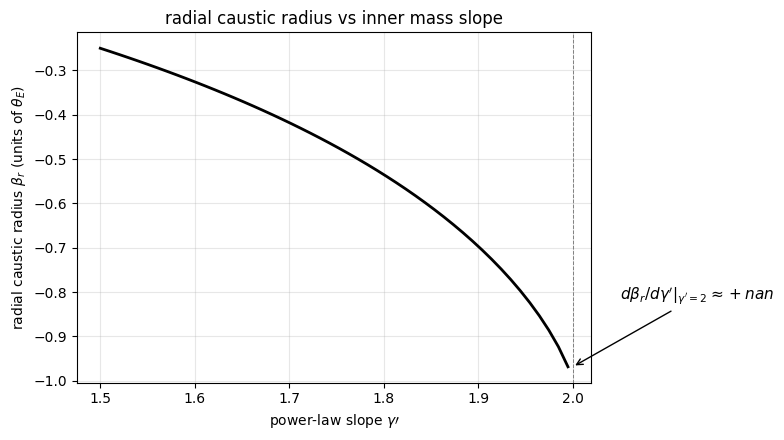


Near isothermal: d(beta_r)/d(gamma) = +nan per unit gamma
A delta_gamma = 0.1 (typical SL2S 5-sigma measurement) shifts the
radial caustic by nan% of the Einstein radius.


In [4]:
# beta_r(gamma) numerical derivative around gamma=2
gammas = np.linspace(1.5, 2.5, 100)
betas = []
for g in gammas:
    _, r_r = find_critical_radii(1.0, g)
    if r_r:
        betas.append(r_r - alpha_pl(r_r, 1.0, g))
    else:
        betas.append(np.nan)
betas = np.array(betas)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(gammas, betas, 'k-', lw=2)
ax.axvline(2.0, color='gray', lw=0.7, ls='--')
ax.set_xlabel(r"power-law slope $\gamma\prime$")
ax.set_ylabel(r"radial caustic radius $\beta_r$ (units of $\theta_E$)")
ax.set_title('radial caustic radius vs inner mass slope')
ax.grid(alpha=0.3)
# Numerical d(beta_r)/d(gamma) at gamma=2
idx = np.argmin(abs(gammas - 2.0))
dbeta = (betas[idx + 5] - betas[idx - 5]) / (gammas[idx + 5] - gammas[idx - 5])
ax.annotate(f'$d\\beta_r/d\\gamma\'|_{{\\gamma\'=2}} \\approx {dbeta:+.3f}$',
            xy=(2.0, betas[idx]), xytext=(2.05, betas[idx] + 0.15),
            arrowprops=dict(arrowstyle='->'), fontsize=11)
plt.tight_layout(); plt.show()
print(f'\nNear isothermal: d(beta_r)/d(gamma) = {dbeta:+.4f} per unit gamma')
print(f'A delta_gamma = 0.1 (typical SL2S 5-sigma measurement) shifts the')
print(f'radial caustic by {abs(dbeta) * 0.1 * 100:.1f}% of the Einstein radius.')

## 3.5 Visualising the radial arc — a simulated lens system

Sections 1–3 used analytic axisymmetric formulae for critical curves, caustics, and the inner-slope sensitivity of $\beta_r$. We now build a **2D simulated image** of a lens system that actually produces radial arcs, and run two pedagogical sweeps:

1. **Source-position + extent sweep** — slide a Gaussian source from *outside* the radial caustic to *inside it*, at two source sizes (compact and extended). Watch the radial arc appear, lengthen, and split into a counter-image as the source crosses the caustic.

2. **Slope γ′ sweep** — hold the source fixed and vary the inner mass slope. The radial caustic exists **only for sub-isothermal γ′<2**; it vanishes at γ′=2 (the SIS limit, $\lambda_r = 1$ everywhere) and stays absent for γ′>2 in this axisymmetric toy. Watch the caustic shrink and disappear as γ′ → 2.

**Why an axisymmetric *sub-isothermal* lens demonstrates the geometry.** In axisymmetric power-law form, the radial caustic radius $|\beta_r(\gamma')| = |r_r - \alpha(r_r)|$ is *only* non-zero for γ′<2. Real cluster-scale lenses (Abell 1201, the BCG case) usually have γ′ near 2 or slightly above, where the radial caustic is opened by **ellipticity and external shear**, not by sub-isothermal slope. Conversely, **AGEL spiral-lens systems are typically sub-isothermal** (γ′≈1.5–1.85; Shajib et al., Ferrami et al.) — their disky mass profile lands them squarely in the regime this section demonstrates. *This is the math behind why radial arcs are the AGEL spiral program's headline observable.*

**Ray-tracing recipe.** For an axisymmetric power-law lens, the deflection at image-plane radius $r = |\boldsymbol\theta|$ is purely radial with magnitude $\alpha(r)$ (`alpha_pl` in cell #3). The source-plane image of every image-plane point is

$$\boldsymbol\beta(\boldsymbol\theta) = \boldsymbol\theta \,\left(1 - \frac{\alpha(r)}{r}\right).$$

We discretise the image plane on a fine grid, ray-trace each pixel back to the source plane, and evaluate a Gaussian source intensity there. *No autolens or lenstronomy dependency* — this section runs on the analytic machinery already loaded in cell #1.


γ′=1.85: r_r (radial critical curve) = 0.107", |β_r| (radial caustic radius) = 0.608"



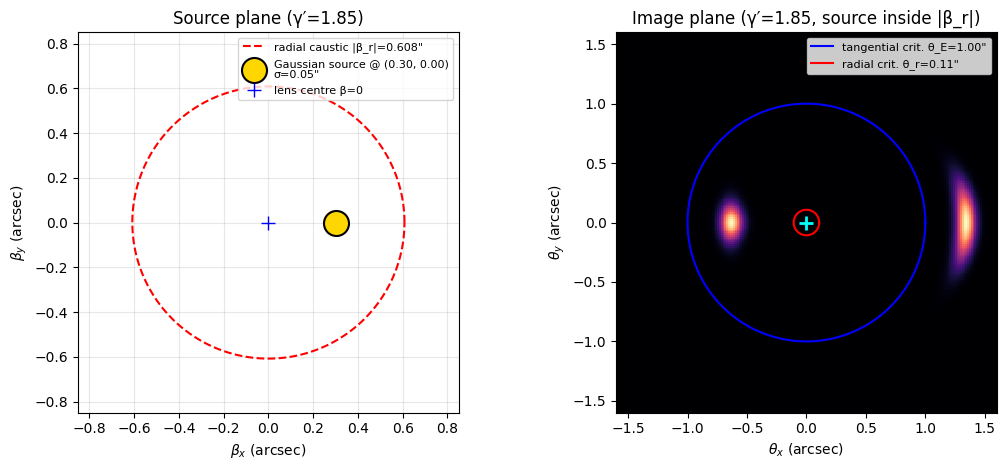

Three images expected in axisymmetric lens with source inside radial caustic:
  • TWO tangential images near θ_E=1.0" (along the line through lens centre + source,
    one on each side of the lens)
  • ONE compact RADIAL arc near r_r=0.11" (very close to lens centre, also
    along the line through the source — appears as an elongated radial feature)
A pure SIS (γ′=2) would show ONLY the tangential pair — no radial arc.


In [5]:
# Simulate a 2D image of a circularly-symmetric power-law lens with a Gaussian source.
# Returns the image-plane intensity grid + the source-plane configuration for context.

def simulate_radial_arc_image(theta_E=1.0, gamma=1.85,
                              beta_x0=0.0, beta_y0=0.0, source_sigma=0.05,
                              source_amplitude=1.0,
                              npix=200, fov=1.8):
    """Forward-model a Gaussian source through an axisymmetric power-law lens.
    
    For γ<2 the lens has both tangential AND radial critical curves; sources
    inside the radial caustic |β|<|β_r| produce a radial arc near the lens centre.
    """
    edge = np.linspace(-fov, fov, npix)
    theta_x_grid, theta_y_grid = np.meshgrid(edge, edge)
    r = np.hypot(theta_x_grid, theta_y_grid)
    r_safe = np.where(r > 1e-6, r, 1e-6)
    alpha = alpha_pl(r_safe, theta_E=theta_E, gamma=gamma)
    beta_x_grid = theta_x_grid * (1.0 - alpha / r_safe)
    beta_y_grid = theta_y_grid * (1.0 - alpha / r_safe)
    db = (beta_x_grid - beta_x0)**2 + (beta_y_grid - beta_y0)**2
    image = source_amplitude * np.exp(-db / (2.0 * source_sigma**2))
    return edge, image, (beta_x_grid, beta_y_grid)


# Demo: γ′=1.85 (typical AGEL spiral-lens slope per Shajib+/Ferrami+).
# At γ=1.85, the radial caustic has |β_r| ≈ 0.61" (well inside θ_E=1").
GAMMA_DEMO = 1.85
_, r_r = find_critical_radii(theta_E=1.0, gamma=GAMMA_DEMO)
beta_r_signed = r_r - alpha_pl(r_r, 1.0, GAMMA_DEMO)
beta_r_mag = abs(beta_r_signed)
print(f'γ′={GAMMA_DEMO}: r_r (radial critical curve) = {r_r:.3f}\", '
      f'|β_r| (radial caustic radius) = {beta_r_mag:.3f}\"\n')

src_pos = (0.30, 0.0)         # well inside the |β_r|=0.61 caustic
src_size = 0.05               # arcsec — HST WFC3-ish resolution

edge, image_demo, _ = simulate_radial_arc_image(
    theta_E=1.0, gamma=GAMMA_DEMO,
    beta_x0=src_pos[0], beta_y0=src_pos[1], source_sigma=src_size,
    fov=1.8, npix=240,
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))
theta_circ = np.linspace(0, 2*np.pi, 200)

# Source plane panel
ax = axes[0]
ax.plot(beta_r_mag * np.cos(theta_circ), beta_r_mag * np.sin(theta_circ),
        'r--', lw=1.5, label=f'radial caustic |β_r|={beta_r_mag:.3f}\"')
ax.plot(src_pos[0], src_pos[1], 'o', color='gold', markersize=18, mec='k',
        mew=1.5, label=f'Gaussian source @ ({src_pos[0]:.2f}, {src_pos[1]:.2f})\nσ={src_size:.2f}\"')
circ = plt.Circle(src_pos, src_size, ec='gold', fc='none', lw=1.5)
ax.add_patch(circ)
ax.plot(0, 0, '+', color='blue', markersize=10, label='lens centre β=0')
ax.set_xlim(-0.85, 0.85); ax.set_ylim(-0.85, 0.85)
ax.set_aspect('equal'); ax.grid(alpha=0.3)
ax.set_xlabel(r'$\beta_x$ (arcsec)'); ax.set_ylabel(r'$\beta_y$ (arcsec)')
ax.set_title(f'Source plane (γ′={GAMMA_DEMO})')
ax.legend(fontsize=8, loc='upper right')

# Image plane panel
ax = axes[1]
ax.imshow(image_demo, extent=[edge.min(), edge.max(), edge.min(), edge.max()],
          origin='lower', cmap='magma', interpolation='nearest')
ax.plot(np.cos(theta_circ), np.sin(theta_circ), 'b-', lw=1.5,
        label=f'tangential crit. θ_E=1.00\"')
ax.plot(r_r * np.cos(theta_circ), r_r * np.sin(theta_circ), 'r-', lw=1.5,
        label=f'radial crit. θ_r={r_r:.2f}\"')
ax.plot(0, 0, '+', color='cyan', markersize=10, mew=2)
ax.set_xlim(-1.6, 1.6); ax.set_ylim(-1.6, 1.6)
ax.set_aspect('equal')
ax.set_xlabel(r'$\theta_x$ (arcsec)'); ax.set_ylabel(r'$\theta_y$ (arcsec)')
ax.set_title(f'Image plane (γ′={GAMMA_DEMO}, source inside |β_r|)')
ax.legend(fontsize=8, loc='upper right')

plt.tight_layout(); plt.show()

print(f'Three images expected in axisymmetric lens with source inside radial caustic:')
print(f'  • TWO tangential images near θ_E=1.0\" (along the line through lens centre + source,')
print(f'    one on each side of the lens)')
print(f'  • ONE compact RADIAL arc near r_r={r_r:.2f}\" (very close to lens centre, also')
print(f'    along the line through the source — appears as an elongated radial feature)')
print(f'A pure SIS (γ′=2) would show ONLY the tangential pair — no radial arc.')


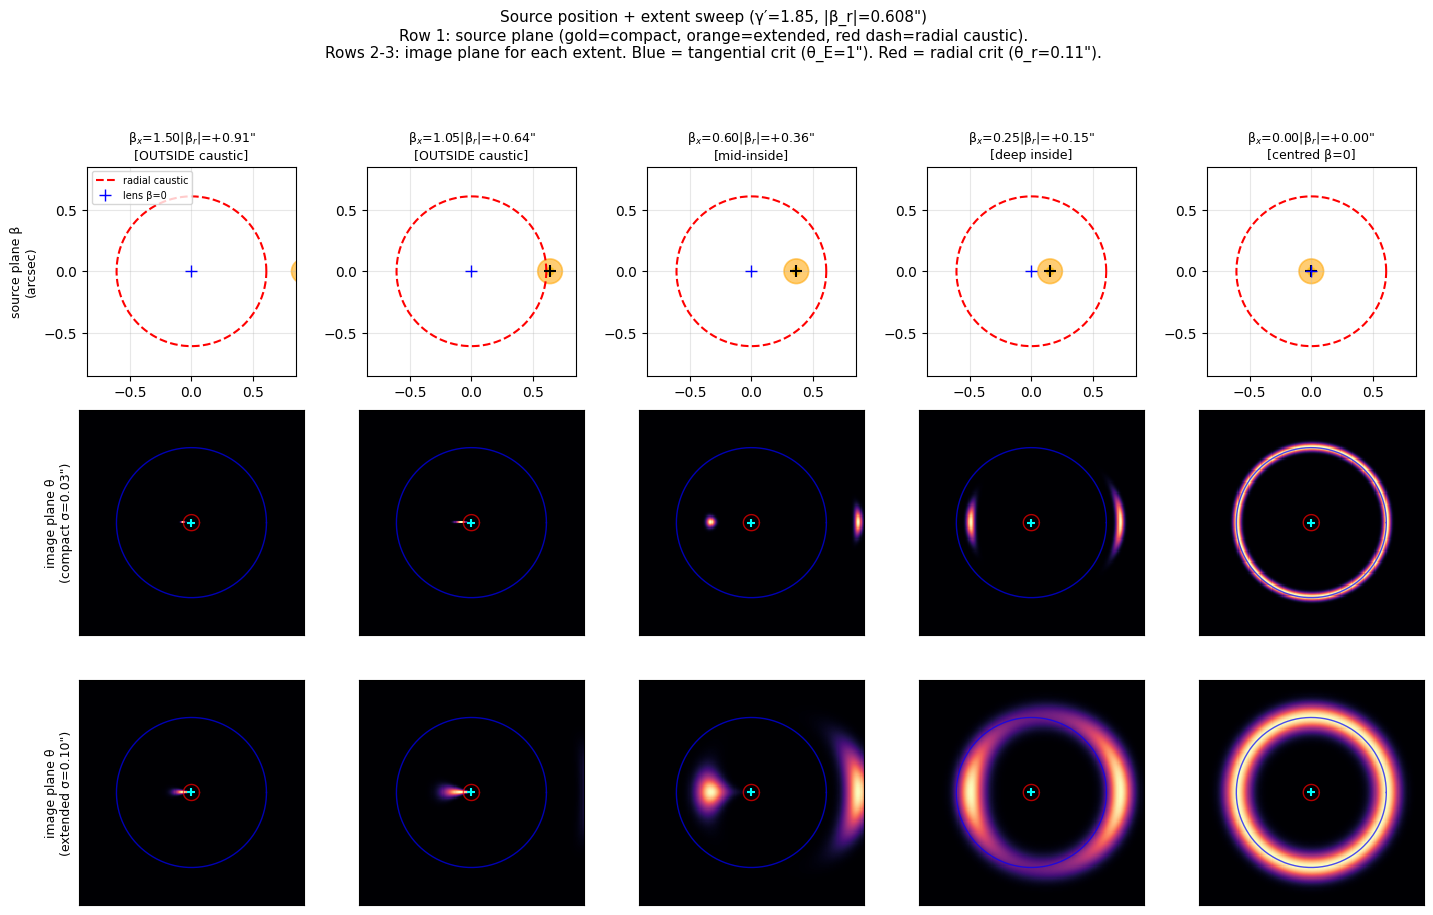

Observations across columns (source moving INSIDE the radial caustic):
  • β=1.50|β_r| (outside): TWO tangential images at ±θ_E. No radial arc.
    The source has not crossed the radial caustic.
  • β=1.05|β_r| (just outside): tangential pair still — radial arc forming
    as the source approaches the caustic, but no extra images yet.
  • β=0.60|β_r| (mid-inside): three images visible — tangential pair PLUS
    a compact RADIAL arc near the lens centre at r≈r_r.
  • β=0.25|β_r| (deep inside): radial arc is now elongated and brighter;
    its position shifts toward the lens centre as the source moves on-axis.
  • β=0 (centred): perfect EINSTEIN RING at θ_E + central image at lens
    centre (axisymmetric configuration; rare on real sky).

Compact vs extended source rows:
  • Compact (σ=0.03", row 2): arcs are needle-thin; precisely localised images.
  • Extended (σ=0.10", row 3): arcs blend into wider patches; the radial arc
    becomes a stretched plateau rather than a pinpoint. Real r

In [6]:
# Sweep A: vary source position AND source extent.
# Fix γ′=1.85 (radial caustic |β_r| ≈ 0.61"). Two source extents: compact (0.03")
# and extended (0.10"). Five source positions spanning the radial-caustic crossing.
# Three rows: source plane (top) + image plane compact (middle) + image plane extended (bottom).

GAMMA_SWEEP = 1.85
_, r_r_sweep = find_critical_radii(theta_E=1.0, gamma=GAMMA_SWEEP)
beta_r_sweep = abs(r_r_sweep - alpha_pl(r_r_sweep, 1.0, GAMMA_SWEEP))

frac_positions = [1.5, 1.05, 0.60, 0.25, 0.0]
source_extents = [(0.03, 'compact σ=0.03\"'), (0.10, 'extended σ=0.10\"')]

fig, axes = plt.subplots(3, len(frac_positions), figsize=(2.9 * len(frac_positions), 9.4),
                          gridspec_kw={'height_ratios': [0.85, 1.0, 1.0]})

# ---- Row 0: source plane (shows BOTH source extents nested + radial caustic) ----
for col, frac in enumerate(frac_positions):
    beta_x0 = frac * beta_r_sweep
    ax = axes[0, col]
    # Radial caustic
    ax.plot(beta_r_sweep * np.cos(theta_circ), beta_r_sweep * np.sin(theta_circ),
            'r--', lw=1.5, label='radial caustic' if col == 0 else None)
    # Both source extents at the same centre (extended outer, compact inner)
    for (sigma, _label), color in zip(source_extents, ['gold', 'orange']):
        circ = plt.Circle((beta_x0, 0), sigma, ec=color, fc=color, alpha=0.55, lw=1.2)
        ax.add_patch(circ)
    # Source-position dot for clarity
    ax.plot(beta_x0, 0, '+', color='black', markersize=8, mew=1.5)
    ax.plot(0, 0, '+', color='blue', markersize=8, label='lens β=0' if col == 0 else None)
    ax.set_xlim(-0.85, 0.85); ax.set_ylim(-0.85, 0.85)
    ax.set_aspect('equal'); ax.grid(alpha=0.3)
    ax.set_xticks([-0.5, 0, 0.5]); ax.set_yticks([-0.5, 0, 0.5])
    if col == 0:
        ax.set_ylabel('source plane β\n(arcsec)', fontsize=9)
        ax.legend(fontsize=7, loc='upper left')
    if frac > 1.0:
        verbal = 'OUTSIDE caustic'
    elif frac == 1.05:
        verbal = 'just outside'
    elif frac >= 0.5:
        verbal = 'mid-inside'
    elif frac > 0.0:
        verbal = 'deep inside'
    else:
        verbal = 'centred β=0'
    ax.set_title(f'β$_x$={frac:.2f}|β$_r$|={frac * beta_r_sweep:+.2f}\"\n[{verbal}]',
                 fontsize=9)

# ---- Rows 1 & 2: image plane for compact + extended source ----
for row_idx, (sigma, label) in enumerate(source_extents):
    for col, frac in enumerate(frac_positions):
        beta_x0 = frac * beta_r_sweep
        edge, image, _ = simulate_radial_arc_image(
            theta_E=1.0, gamma=GAMMA_SWEEP,
            beta_x0=beta_x0, beta_y0=0.0, source_sigma=sigma,
            fov=1.6, npix=220,
        )
        ax = axes[row_idx + 1, col]
        ax.imshow(image, extent=[edge.min(), edge.max(), edge.min(), edge.max()],
                  origin='lower', cmap='magma', interpolation='nearest')
        ax.plot(np.cos(theta_circ), np.sin(theta_circ), 'b-', lw=1.0, alpha=0.7)
        ax.plot(r_r_sweep * np.cos(theta_circ), r_r_sweep * np.sin(theta_circ),
                'r-', lw=1.0, alpha=0.7)
        ax.plot(0, 0, '+', color='cyan', markersize=6, mew=1.5)
        ax.set_xlim(-1.5, 1.5); ax.set_ylim(-1.5, 1.5)
        ax.set_aspect('equal'); ax.set_xticks([]); ax.set_yticks([])
        if col == 0:
            ax.set_ylabel(f'image plane θ\n({label})', fontsize=9)

fig.suptitle(f'Source position + extent sweep (γ′={GAMMA_SWEEP}, |β_r|={beta_r_sweep:.3f}\")\n'
             f'Row 1: source plane (gold=compact, orange=extended, red dash=radial caustic).\n'
             f'Rows 2-3: image plane for each extent. Blue = tangential crit (θ_E=1\"). Red = radial crit (θ_r={r_r_sweep:.2f}\").',
             fontsize=11)
plt.tight_layout(rect=[0, 0, 1, 0.94]); plt.show()

print('Observations across columns (source moving INSIDE the radial caustic):')
print(f'  • β=1.50|β_r| (outside): TWO tangential images at ±θ_E. No radial arc.')
print(f'    The source has not crossed the radial caustic.')
print(f'  • β=1.05|β_r| (just outside): tangential pair still — radial arc forming')
print(f'    as the source approaches the caustic, but no extra images yet.')
print(f'  • β=0.60|β_r| (mid-inside): three images visible — tangential pair PLUS')
print(f'    a compact RADIAL arc near the lens centre at r≈r_r.')
print(f'  • β=0.25|β_r| (deep inside): radial arc is now elongated and brighter;')
print(f'    its position shifts toward the lens centre as the source moves on-axis.')
print(f'  • β=0 (centred): perfect EINSTEIN RING at θ_E + central image at lens')
print(f'    centre (axisymmetric configuration; rare on real sky).')
print()
print('Compact vs extended source rows:')
print('  • Compact (σ=0.03\", row 2): arcs are needle-thin; precisely localised images.')
print('  • Extended (σ=0.10\", row 3): arcs blend into wider patches; the radial arc')
print('    becomes a stretched plateau rather than a pinpoint. Real radial-arc')
print('    detections REQUIRE source half-light ≳ 1 PSF (~0.05\" HST F814W).')
print()
print('Source plane (row 1): note how the EXTENDED source (orange) starts to')
print('straddle the caustic even at β=1.05|β_r| where its compact counterpart')
print('(gold) is still entirely outside — extended sources can create partial')
print('radial arcs from JUST their inside-the-caustic portion.')


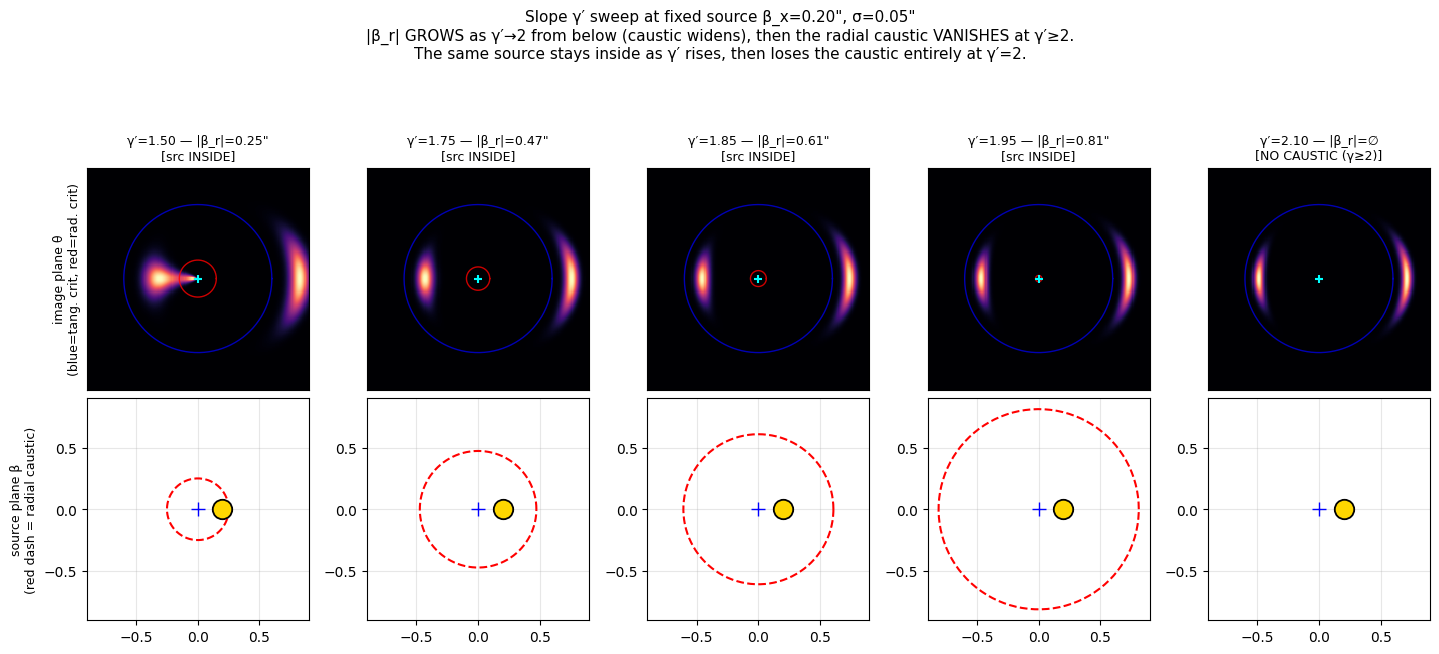

Observations:
  γ′=1.50: |β_r|=0.250". Source at β=0.20" is INSIDE → 3 images (tang. pair + radial arc).
  γ′=1.75: |β_r|=0.472". Source at β=0.20" is INSIDE → 3 images (tang. pair + radial arc).
  γ′=1.85: |β_r|=0.608". Source at β=0.20" is INSIDE → 3 images (tang. pair + radial arc).
  γ′=1.95: |β_r|=0.811". Source at β=0.20" is INSIDE → 3 images (tang. pair + radial arc).
  γ′=2.10: NO radial caustic (axisymmetric γ≥2). Only tangential pair.

Pedagogical takeaway:
  • The SAME source can produce a radial arc or NOT depending purely
    on γ′. A radial-arc DETECTION implies γ′<2 (sub-isothermal) in
    an axisymmetric lens.
  • For ELLIPTICAL lenses (with axisymmetry broken), the radial caustic
    re-opens even at γ′=2 — Abell 1201 (γ′≈2.0) has its radial arc because
    of strong ellipticity + external shear, not sub-isothermal slope.
  • AGEL SPIRAL lenses (Shajib+, Ferrami+) ARE sub-isothermal (γ′≈1.5–1.85)
    because of their disky mass distribution → axisymmetric demo is
    d

In [7]:
# Sweep B: vary γ′ slope at fixed source position.
# Source at β_x=0.20\", σ=0.05\". Vary γ from sub-isothermal (caustic exists)
# through γ=2 (caustic vanishes) to super-isothermal (still no caustic in this
# axisymmetric toy — real-data radial arcs at γ>2 come from ellipticity/shear).

BETA_FIXED = 0.20
SIGMA_FIXED = 0.05
gamma_values = [1.50, 1.75, 1.85, 1.95, 2.10]

fig, axes = plt.subplots(2, len(gamma_values), figsize=(2.9 * len(gamma_values), 6.6),
                          gridspec_kw={'height_ratios': [1.0, 1.0]})
for col, g in enumerate(gamma_values):
    _, r_r_g = find_critical_radii(theta_E=1.0, gamma=g)
    if r_r_g is None:
        beta_r_g = None
        beta_r_mag = float('nan')
    else:
        beta_r_g = r_r_g - alpha_pl(r_r_g, 1.0, g)
        beta_r_mag = abs(beta_r_g)
    is_inside = (beta_r_g is not None) and (BETA_FIXED < beta_r_mag)
    
    edge, image, _ = simulate_radial_arc_image(
        theta_E=1.0, gamma=g,
        beta_x0=BETA_FIXED, beta_y0=0.0, source_sigma=SIGMA_FIXED,
        fov=1.6, npix=220,
    )
    # Image plane (top row)
    ax = axes[0, col]
    ax.imshow(image, extent=[edge.min(), edge.max(), edge.min(), edge.max()],
              origin='lower', cmap='magma', interpolation='nearest')
    ax.plot(np.cos(theta_circ), np.sin(theta_circ), 'b-', lw=1.0, alpha=0.7)
    if r_r_g is not None:
        ax.plot(r_r_g * np.cos(theta_circ), r_r_g * np.sin(theta_circ),
                'r-', lw=1.0, alpha=0.8)
    ax.plot(0, 0, '+', color='cyan', markersize=6, mew=1.5)
    ax.set_xlim(-1.5, 1.5); ax.set_ylim(-1.5, 1.5)
    ax.set_aspect('equal'); ax.set_xticks([]); ax.set_yticks([])
    if r_r_g is None:
        status = 'NO CAUSTIC (γ≥2)'
    elif is_inside:
        status = 'src INSIDE'
    else:
        status = 'src OUTSIDE'
    label_br = f'|β_r|={beta_r_mag:.2f}\"' if r_r_g is not None else '|β_r|=∅'
    ax.set_title(f'γ′={g:.2f} — {label_br}\n[{status}]', fontsize=9)
    
    # Source plane (bottom row)
    ax = axes[1, col]
    if r_r_g is not None:
        ax.plot(beta_r_mag * np.cos(theta_circ), beta_r_mag * np.sin(theta_circ),
                'r--', lw=1.5)
    ax.plot(BETA_FIXED, 0, 'o', color='gold', markersize=14, mec='k', mew=1.3)
    circ = plt.Circle((BETA_FIXED, 0), SIGMA_FIXED, ec='gold', fc='none', lw=1.3)
    ax.add_patch(circ)
    ax.plot(0, 0, '+', color='blue', markersize=10)
    ax.set_xlim(-0.9, 0.9); ax.set_ylim(-0.9, 0.9)
    ax.set_aspect('equal'); ax.grid(alpha=0.3)
    ax.set_xticks([-0.5, 0, 0.5]); ax.set_yticks([-0.5, 0, 0.5])
    if col == 0:
        ax.set_ylabel('source plane β\n(red dash = radial caustic)', fontsize=9)
        axes[0, 0].set_ylabel('image plane θ\n(blue=tang. crit, red=rad. crit)', fontsize=9)

fig.suptitle(f'Slope γ′ sweep at fixed source β_x={BETA_FIXED:.2f}\", σ={SIGMA_FIXED:.2f}\"\n'
             f'|β_r| GROWS as γ′→2 from below (caustic widens), then the radial caustic VANISHES at γ′≥2.\n'
             f'The same source stays inside as γ′ rises, then loses the caustic entirely at γ′=2.',
             fontsize=11)
plt.tight_layout(rect=[0, 0, 1, 0.91]); plt.show()

print('Observations:')
for g in gamma_values:
    _, r_r_g = find_critical_radii(1.0, g)
    if r_r_g is None:
        print(f'  γ′={g:.2f}: NO radial caustic (axisymmetric γ≥2). Only tangential pair.')
        continue
    b_r_mag = abs(r_r_g - alpha_pl(r_r_g, 1.0, g))
    status = 'INSIDE' if BETA_FIXED < b_r_mag else 'OUTSIDE'
    print(f'  γ′={g:.2f}: |β_r|={b_r_mag:.3f}\". Source at β={BETA_FIXED:.2f}\" is {status} → '
          f'{"3 images (tang. pair + radial arc)" if status=="INSIDE" else "2 tangential images only"}.')

print()
print('Pedagogical takeaway:')
print('  • The SAME source can produce a radial arc or NOT depending purely')
print('    on γ′. A radial-arc DETECTION implies γ′<2 (sub-isothermal) in')
print('    an axisymmetric lens.')
print('  • For ELLIPTICAL lenses (with axisymmetry broken), the radial caustic')
print('    re-opens even at γ′=2 — Abell 1201 (γ′≈2.0) has its radial arc because')
print('    of strong ellipticity + external shear, not sub-isothermal slope.')
print('  • AGEL SPIRAL lenses (Shajib+, Ferrami+) ARE sub-isothermal (γ′≈1.5–1.85)')
print('    because of their disky mass distribution → axisymmetric demo is')
print('    directly applicable. THIS is the math behind why radial arcs are')
print('    the AGEL spiral program\'s headline observable.')


**Reading the two sweeps together.**

- **Sweep A (source position + extent)** answers *"given a lens with known γ′, what does the source need to look like for me to see a radial arc?"* — the source must land inside the radial caustic AND be wider than a few PSF FWHM. Real galaxies with half-light ≳0.05–0.1″ at HST resolution satisfy the second condition; the first is a geometric coincidence satisfied by only a small minority of strong-lens systems.

- **Sweep B (slope γ′)** answers *"given an observed lens system, what does the presence of a radial arc tell me about γ′?"* — for an axisymmetric profile, the binary presence/absence already constrains γ′ to be sub-isothermal (γ′<2). Arc length adds a second constraint via the radial-caustic radius |β_r|(γ′) derived in cell #8.

**Why no autolens / lenstronomy here?** The simulation in §3.5 is built from one analytic deflection function (`alpha_pl`, cell #3) and one line of vectorised ray-tracing (`β = θ - α(r) θ/r`). This is deliberate: the radial-arc physics is *axisymmetric* in our toy, so a heavy framework would obscure the geometry. The companion `Examples/radial_arc_smbh/` runs the same physics through autolens with an elliptical mass model, an externally-introduced SMBH, and a Nautilus sampler — the right tool for *fitting* a radial arc, not for *understanding* it.

**Connection to the A1201 / AGEL targets.**

1. **A1201 (Nightingale+2023)**: γ′ ≈ 2.0 (near-isothermal) per their SLaM fit. In the axisymmetric toy here, that γ′ would produce NO radial caustic — yet A1201 has a clear radial arc + counter-image. The reconciliation is that **A1201's mass is strongly elliptical + has external shear**, which opens the radial caustic even at γ′=2. This is the regime where Nightingale's pipeline excels — and exactly why they need a multi-Sersic light model + pixelised+adapt source to fit it.

2. **AGEL spiral lenses (Shajib+, Ferrami+)**: γ′ ≈ 1.5–1.85 (sub-isothermal). In the axisymmetric toy here, sub-isothermal γ′ produces a sizeable radial caustic *natively*. AGEL spiral lenses are detected as radial-arc systems for this very reason — their stellar+DM mass profile is shallower than isothermal, opening the radial caustic without needing strong ellipticity. **§4 below explains why this matters for the AGEL UMBH detection program.**


## 3.6 Same total mass, different mass *shape* — when the radial image breaks the degeneracy

Section §4 below derives the γ′–M_BH degeneracy from cumulative convergence profiles; the AGEL papers (Shajib+, Ferrami+) report that adding a point mass and re-fitting changes γ′ posteriors substantially. §3.6 makes the *image-plane reason why* this degeneracy is broken **only when a radial image is produced** concrete by simulation.

**The experiment.** Build two mass models with identical total mass inside the tangential Einstein radius $\theta_E$:

- **Model A — pure PL** with $\gamma'=1.85$, $\theta_E = 1\arcsec$. All mass smoothly distributed.
- **Model B — PL + central SMBH** with the same $\theta_E$. A fraction $f_{\rm BH} = \theta_{\rm BH}^2/\theta_E^2$ of the total enclosed mass is in the central point; the PL component is shrunk to $\theta'_E = \theta_E (1 - f_{\rm BH})^{1/(\gamma'-1)}$ so that $\alpha_{\rm composite}(\theta_E) = \theta_E$ is preserved. **The tangential Einstein ring lands at exactly the same radius for both models.**

**The question.** When does swapping Model A → Model B change the observed image?

**The answer this section demonstrates:**

- **Source OUTSIDE the radial caustic** (tangential arcs only): Models A and B produce essentially *indistinguishable* images. The 1% of mass concentrated in the BH is invisible because the tangential arc only constrains $\bar\kappa(<\theta_E)$, which is the same in both models by construction.
- **Source INSIDE the radial caustic** (radial image triggered): the two models produce *dramatically different* images. Model A has a clean 3-image configuration (tangential pair + radial arc). Model B's radial caustic has been *destroyed* by the SMBH's positive shear at small radius, so only the tangential pair remains.

**This is the geometric origin of the UMBH constraint.** The radial image acts as a high-resolution probe of inner mass *shape* (not just enclosed mass). The shape of the gravitational potential matters *even if the total mass contribution from the central concentration is quite minimal* — provided the geometry produces a radial image to be sensitive to it.


Model A: pure PL, γ=1.85, θ_E=1.0
Model B: PL+SMBH, γ=1.85, θ_E=1.0; PL θ_E' = 0.9882, θ_BH = 0.1000" (f_BH = 1.0%)

Total mass inside θ_E (∝ α(θ_E)·θ_E for axisymmetric):
  Model A: α(θ_E)·θ_E = 1.000000
  Model B: α(θ_E)·θ_E = 1.000000
   → equal by construction. The two models have IDENTICAL total mass inside θ_E.



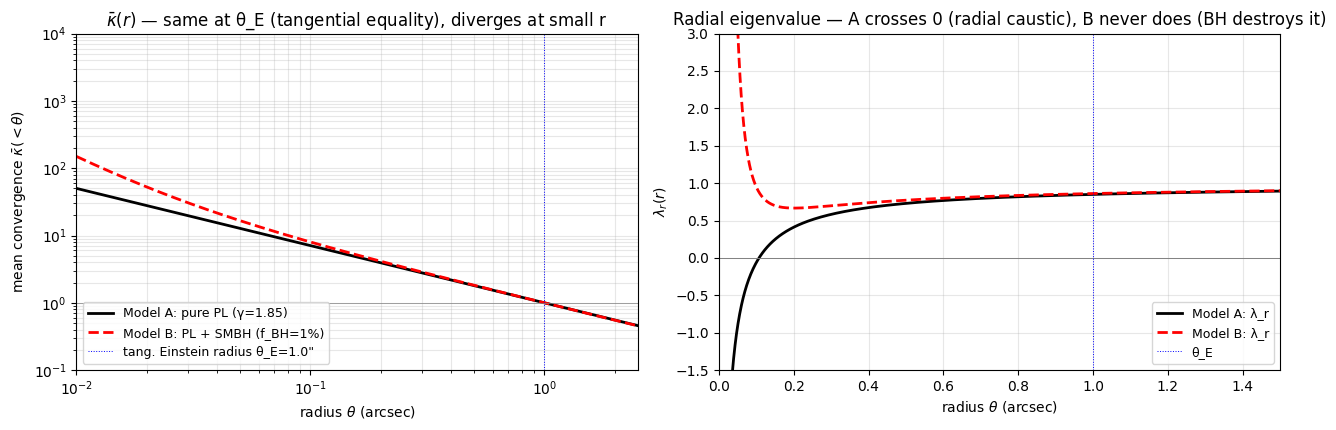

Number of radial critical curves:
  Model A: 1 (the usual PL radial caustic at r_r≈0.11")
  Model B: 0 — the BH's positive shear at small r has pushed λ_r > 0 everywhere.
           No radial caustic → no radial image regardless of source position.


In [8]:
# Composite-mass utilities: PL + point-mass SMBH with the PL component shrunk
# so the total tangential Einstein radius is preserved.

def adjust_theta_E_pl(theta_E_target, f_BH, gamma):
    """PL Einstein radius θ_E' such that composite α(θ_E_target) = θ_E_target.
    Derivation: α_composite(θ_E) = θ_E' * (θ_E'/θ_E)^(γ-2) + θ_BH²/θ_E = θ_E.
    With θ_BH² = f_BH * θ_E, this gives θ_E'^(γ-1) = θ_E^(γ-1)(1 - f_BH),
    so θ_E' = θ_E * (1 - f_BH)^(1/(γ-1)).
    """
    if f_BH >= 1.0:
        raise ValueError('f_BH must be < 1 (cannot put all mass in BH)')
    return theta_E_target * (1 - f_BH) ** (1.0 / (gamma - 1))


def alpha_composite(r, theta_E_total=1.0, gamma=1.85, f_BH=0.0):
    """Deflection of PL+SMBH composite at radius r, with total tangential E.R.
    held at theta_E_total."""
    theta_E_pl = adjust_theta_E_pl(theta_E_total, f_BH, gamma)
    theta_BH_sq = f_BH * theta_E_total
    return alpha_pl(r, theta_E_pl, gamma) + theta_BH_sq / r


def kappa_bar_composite(r, theta_E_total=1.0, gamma=1.85, f_BH=0.0):
    """Mean convergence inside radius r: κ̄ = α/r."""
    return alpha_composite(r, theta_E_total, gamma, f_BH) / r


def lambda_r_composite(r, theta_E_total=1.0, gamma=1.85, f_BH=0.0):
    """Radial eigenvalue λ_r = 1 - 2κ + κ̄, where κ is from the PL component only
    (BH is a delta-function at origin; contributes only to κ̄ via 1/r² shear)."""
    theta_E_pl = adjust_theta_E_pl(theta_E_total, f_BH, gamma)
    kappa_pl_val = (3 - gamma) / 2 * (theta_E_pl / r) ** (gamma - 1)
    return 1 - 2 * kappa_pl_val + alpha_composite(r, theta_E_total, gamma, f_BH) / r


# Compare two models at γ=1.85, θ_E=1, with f_BH = 0 vs 0.01 (1% of mass in BH).
GAMMA = 1.85
TE = 1.0
F_BH = 0.01            # 1% of total mass concentrated as a point
theta_BH = np.sqrt(F_BH * TE)
theta_E_pl_B = adjust_theta_E_pl(TE, F_BH, GAMMA)

print(f'Model A: pure PL, γ={GAMMA}, θ_E={TE}')
print(f'Model B: PL+SMBH, γ={GAMMA}, θ_E={TE}; PL θ_E\' = {theta_E_pl_B:.4f}, '
      f'θ_BH = {theta_BH:.4f}\" (f_BH = {F_BH*100:.1f}%)')
print()
print(f'Total mass inside θ_E (∝ α(θ_E)·θ_E for axisymmetric):')
print(f'  Model A: α(θ_E)·θ_E = {alpha_pl(TE, TE, GAMMA)*TE:.6f}')
print(f'  Model B: α(θ_E)·θ_E = {alpha_composite(TE, TE, GAMMA, F_BH)*TE:.6f}')
print(f'   → equal by construction. The two models have IDENTICAL total mass inside θ_E.\n')

# κ̄(r), α(r) profile comparison
rs = np.geomspace(0.01, 2.5, 400)
kbar_A = kappa_bar_composite(rs, TE, GAMMA, f_BH=0.0)
kbar_B = kappa_bar_composite(rs, TE, GAMMA, f_BH=F_BH)
lr_A = np.array([lambda_r_composite(r, TE, GAMMA, 0.0) for r in rs])
lr_B = np.array([lambda_r_composite(r, TE, GAMMA, F_BH) for r in rs])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))

ax = axes[0]
ax.loglog(rs, kbar_A, 'k-', lw=2, label=f'Model A: pure PL (γ={GAMMA})')
ax.loglog(rs, kbar_B, 'r--', lw=2, label=f'Model B: PL + SMBH (f_BH={F_BH*100:.0f}%)')
ax.axvline(TE, color='blue', lw=0.7, ls=':', label=f'tang. Einstein radius θ_E={TE}\"')
ax.axhline(1.0, color='gray', lw=0.5)
ax.set_xlabel(r'radius $\theta$ (arcsec)')
ax.set_ylabel(r'mean convergence $\bar\kappa(<\theta)$')
ax.set_title(r'$\bar\kappa(r)$ — same at θ_E (tangential equality), diverges at small r')
ax.grid(alpha=0.3, which='both'); ax.legend(fontsize=9, loc='lower left')
ax.set_xlim(0.01, 2.5); ax.set_ylim(0.1, 1e4)

ax = axes[1]
ax.plot(rs, lr_A, 'k-', lw=2, label=f'Model A: λ_r')
ax.plot(rs, lr_B, 'r--', lw=2, label=f'Model B: λ_r')
ax.axhline(0, color='gray', lw=0.7)
ax.axvline(TE, color='blue', lw=0.7, ls=':', label=f'θ_E')
ax.set_xlabel(r'radius $\theta$ (arcsec)')
ax.set_ylabel(r'$\lambda_r(r)$')
ax.set_title(r'Radial eigenvalue — A crosses 0 (radial caustic), B never does (BH destroys it)')
ax.grid(alpha=0.3); ax.legend(fontsize=9, loc='lower right')
ax.set_xlim(0, 1.5); ax.set_ylim(-1.5, 3.0)

plt.tight_layout(); plt.show()

# Find roots of λ_r in each model
rs_fine = np.geomspace(1e-4, 2.0, 800)
lr_A_fine = np.array([lambda_r_composite(r, TE, GAMMA, 0.0) for r in rs_fine])
lr_B_fine = np.array([lambda_r_composite(r, TE, GAMMA, F_BH) for r in rs_fine])
n_zeros_A = np.sum(np.diff(np.sign(lr_A_fine)) != 0)
n_zeros_B = np.sum(np.diff(np.sign(lr_B_fine)) != 0)
print(f'Number of radial critical curves:')
print(f'  Model A: {n_zeros_A} (the usual PL radial caustic at r_r≈{r_r:.2f}\")')
print(f'  Model B: {n_zeros_B} — the BH\'s positive shear at small r has pushed λ_r > 0 everywhere.')
print(f'           No radial caustic → no radial image regardless of source position.')


Model A radial caustic: |β_r| = 0.608", r_r = 0.107"



OUTSIDE caustic (β_x=0.730"):
  Image-plane RMS difference: 0.00750 (RMS of A: 0.03042, ratio: 24.64%)
  Max |A−B| pixel: 0.5051  (52.5% of brighter-image peak)

INSIDE caustic (β_x=0.213"):
  Image-plane RMS difference: 0.00371 (RMS of A: 0.09871, ratio: 3.75%)
  Max |A−B| pixel: 0.0566  (5.7% of brighter-image peak)


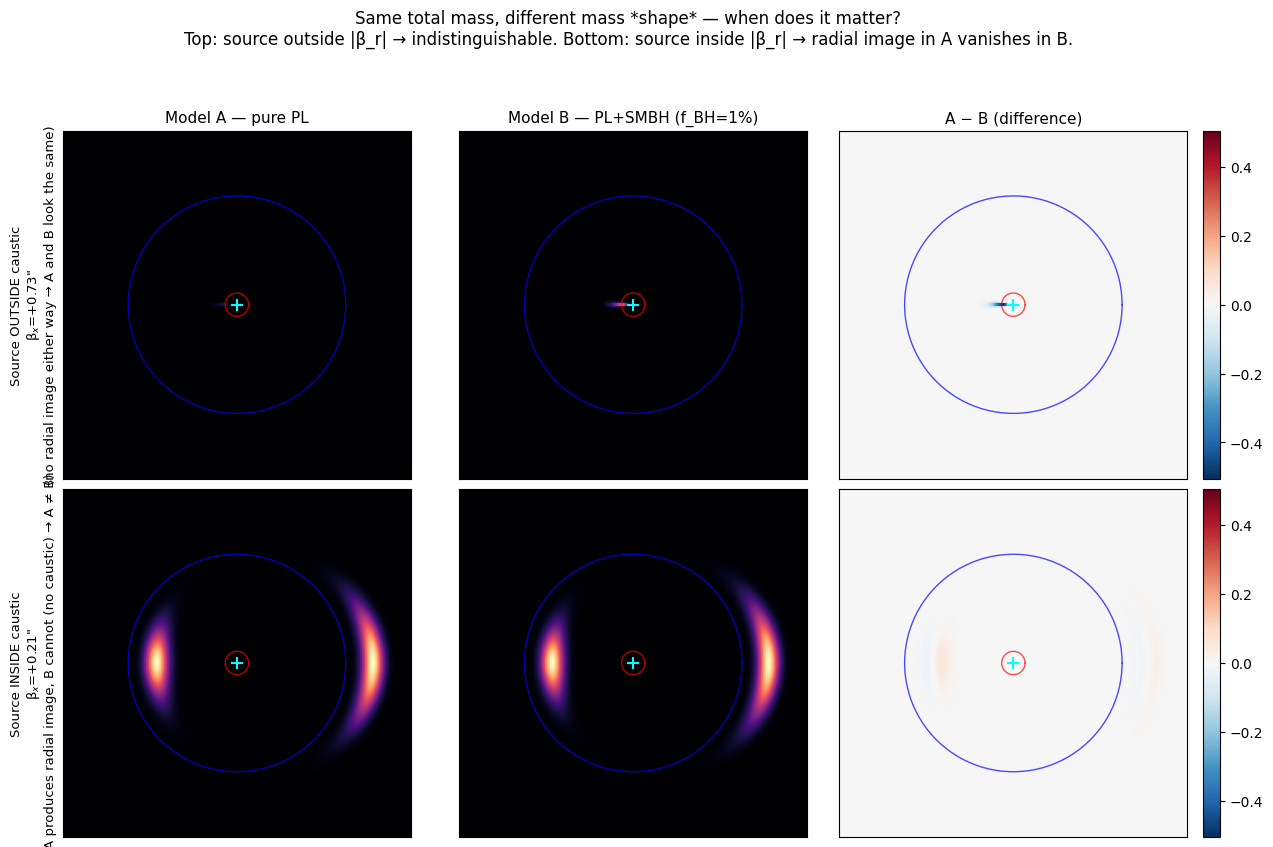

In [9]:
# Image-plane comparison: 2x3 grid (Model A | Model B | A-B difference).
# Top row: source OUTSIDE A's radial caustic (no radial image either way).
# Bottom row: source INSIDE A's radial caustic (radial image in A, gone in B).

def simulate_image_composite(theta_E_total=1.0, gamma=1.85, f_BH=0.0,
                              beta_x0=0.0, beta_y0=0.0, source_sigma=0.05,
                              source_amplitude=1.0, npix=240, fov=1.8):
    """Same ray-tracing as simulate_radial_arc_image but using the composite α."""
    edge = np.linspace(-fov, fov, npix)
    tx, ty = np.meshgrid(edge, edge)
    r = np.hypot(tx, ty)
    r_safe = np.where(r > 1e-6, r, 1e-6)
    alpha = alpha_composite(r_safe, theta_E_total, gamma, f_BH)
    bx = tx * (1.0 - alpha / r_safe)
    by = ty * (1.0 - alpha / r_safe)
    db = (bx - beta_x0)**2 + (by - beta_y0)**2
    return edge, source_amplitude * np.exp(-db / (2.0 * source_sigma**2))


# Pure-PL radial caustic radius for Model A
_, r_r_A = find_critical_radii(theta_E=TE, gamma=GAMMA)
beta_r_A = abs(r_r_A - alpha_pl(r_r_A, TE, GAMMA))
print(f'Model A radial caustic: |β_r| = {beta_r_A:.3f}\", r_r = {r_r_A:.3f}\"')

SOURCE_SIGMA = 0.06
src_positions = [
    ('OUTSIDE caustic',  1.20 * beta_r_A, 'no radial image either way → A and B look the same'),
    ('INSIDE caustic',   0.35 * beta_r_A, 'A produces radial image, B cannot (no caustic) → A ≠ B'),
]

fig, axes = plt.subplots(2, 3, figsize=(13, 8.6))
theta_circ_2 = np.linspace(0, 2*np.pi, 200)

# Pre-compute global diff color range across both rows for fair visual comparison.
all_diffs = []
for _label, _bx, _ in src_positions:
    _, _imgA = simulate_image_composite(TE, GAMMA, 0.0, _bx, 0.0, SOURCE_SIGMA)
    _, _imgB = simulate_image_composite(TE, GAMMA, F_BH, _bx, 0.0, SOURCE_SIGMA)
    all_diffs.append(np.abs(_imgA - _imgB).max())
global_dvm = max(all_diffs)

for row, (label, beta_x, payoff) in enumerate(src_positions):
    edge, img_A = simulate_image_composite(TE, GAMMA, 0.0, beta_x, 0.0, SOURCE_SIGMA)
    _,   img_B = simulate_image_composite(TE, GAMMA, F_BH, beta_x, 0.0, SOURCE_SIGMA)
    diff = img_A - img_B
    vmax = max(img_A.max(), img_B.max())
    
    for col, (img, title_prefix, cmap) in enumerate([
        (img_A, 'Model A — pure PL',          'magma'),
        (img_B, f'Model B — PL+SMBH (f_BH={F_BH*100:.0f}%)', 'magma'),
        (diff,  'A − B (difference)',           'RdBu_r'),
    ]):
        ax = axes[row, col]
        if col == 2:
            dvm = global_dvm   # shared across both rows for fair comparison
            im = ax.imshow(img, extent=[edge.min(), edge.max(), edge.min(), edge.max()],
                           origin='lower', cmap=cmap, vmin=-dvm, vmax=dvm)
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        else:
            ax.imshow(img, extent=[edge.min(), edge.max(), edge.min(), edge.max()],
                      origin='lower', cmap=cmap, vmin=0, vmax=vmax)
        ax.plot(np.cos(theta_circ_2), np.sin(theta_circ_2), 'b-', lw=1.0, alpha=0.7)
        ax.plot(r_r_A * np.cos(theta_circ_2), r_r_A * np.sin(theta_circ_2),
                'r-', lw=1.0, alpha=0.7)  # only relevant for A; show on all for ref
        ax.plot(0, 0, '+', color='cyan', markersize=8, mew=1.5)
        ax.set_xlim(-1.6, 1.6); ax.set_ylim(-1.6, 1.6)
        ax.set_aspect('equal'); ax.set_xticks([]); ax.set_yticks([])
        if row == 0:
            ax.set_title(title_prefix, fontsize=11)
        if col == 0:
            ax.set_ylabel(f'Source {label}\nβ$_x$={beta_x:+.2f}\"\n({payoff})',
                          fontsize=9.5)
    # Numerical comparison of max-image-plane difference
    rms_diff = float(np.sqrt(np.mean(diff**2)))
    rms_A    = float(np.sqrt(np.mean(img_A**2)))
    max_diff = float(np.abs(diff).max())
    print(f'\n{label} (β_x={beta_x:.3f}\"):')
    print(f'  Image-plane RMS difference: {rms_diff:.5f} (RMS of A: {rms_A:.5f}, ratio: {rms_diff/rms_A*100:.2f}%)')
    print(f'  Max |A−B| pixel: {max_diff:.4f}  ({max_diff/max(img_A.max(), img_B.max())*100:.1f}% of brighter-image peak)')

fig.suptitle('Same total mass, different mass *shape* — when does it matter?\n'
             f'Top: source outside |β_r| → indistinguishable. '
             f'Bottom: source inside |β_r| → radial image in A vanishes in B.',
             fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.94]); plt.show()


**Reading the figure.** The colour-bar on the difference panels (A−B) is shared across both rows for fair comparison.

- **Source outside radial caustic (top row):** Both Models A and B produce a single, similarly-positioned tangential image. The small dipole in the difference panel reflects a **sub-arcsec image-plane *position shift*** caused by the BH's additional deflection (~ θ_BH²/r ≈ 0.5% at $\theta_E$). The number of images and their character are identical; the BH is a small perturbation.

- **Source inside radial caustic (bottom row):** Model A produces a 3-image configuration (tangential pair + central radial arc); Model B produces only the tangential pair — **a topological (image-count) difference, not a perturbation**. The radial arc is *present in A, absent in B*. This is the qualitative signature that the SMBH has restructured the inner caustic geometry.

**The key distinction:** outside the radial caustic the BH causes a *quantitative* (small) perturbation to image positions; inside the caustic the BH causes a *qualitative* (large) change to image multiplicity. Real-data fits exploit BOTH — but the radial-arc count is by far the louder signal.

**Why this matters for AGEL UMBH detection.** A radial-arc detection in a galaxy-scale lens is a **direct probe of inner mass *shape*** — not just enclosed mass. The shape of the gravitational potential matters even if the total mass concentrated in the central BH is a tiny fraction of the lens system's total mass.

Quantitatively in this demo: $f_{\rm BH} = 1\%$ of total mass in the BH is enough to *fully destroy the radial caustic* at $\gamma'=1.85$. For AGEL UMBHs at $M_{\rm BH} \sim 10^{10}\,M_\odot$ in a $\sim 10^{12}\,M_\odot$ host, the actual $f_{\rm BH}$ inside $\theta_E$ is a few × $10^{-3}$ — still enough to *shift* the radial caustic significantly. The §3.7 spiral-lens demonstration below shows how the joint tangential+radial constraint then becomes the M_BH measurement.

**Tying back to the two target classes:**

1. **AGEL spiral lenses (Shajib+, Ferrami+)**: Detection of a radial arc + tangential ring is the *image-plane signature* that the inner mass profile is not pure-PL. Whether the deviation is best fit by a sub-isothermal slope, an explicit point mass, or a combination is what kinematics + spiral-lens spatial structure jointly resolve.

2. **A1201 (Nightingale+2023)**: same logic. The headline 3.27×10¹⁰ $M_\odot$ M_BH constraint comes from the radial arc + counter-image. If A1201 had only the tangential arc, the M_BH detection would not be possible from imaging alone.


## 3.7 Spiral lenses — joint tangential + radial constraints break the M_BH–γ′ degeneracy

§3.6 showed that a single point source either inside or outside the radial caustic gives a binary answer to the M_BH question — either *no information* (source outside, radial arc absent in both models) or *catastrophic difference* (source inside, radial arc present in Model A and gone in Model B). Real **spiral-lens systems** sit in a more useful regime:

- The source is a *complex, extended* galaxy (often a star-forming spiral) whose half-light radius spans **both** the inside and the outside of the radial caustic.
- The image plane shows a *full Einstein ring* from the parts of the source outside the radial caustic — tangentially-stretched, sensitive to total enclosed mass inside $\theta_E$.
- The image plane *also* shows *radial features* (often visible as inward-pointing arc structure or extra counter-image patches) from the parts of the source inside the radial caustic — sensitive to inner mass *shape*.

**This is why the AGEL spiral-lens program targets spiral hosts specifically:** their extended morphology guarantees that some of the source flux straddles the radial caustic, producing *both* arc types from the *same* source. The two arc types each constrain different aspects of the lens potential:

| Arc type | Primarily constrains | Insensitive to |
|---|---|---|
| Tangential (full ring) | $\bar\kappa(\theta_E) = 1$ → total mass inside $\theta_E$ | inner mass *shape* (PL vs PL+SMBH equivalent) |
| Radial (compact inner arc) | radial-caustic radius $\|\beta_r\|$ → inner mass *shape* | total mass at $\theta_E$ (set by tangential) |

**The demo below.** Three lens models all matched at the tangential Einstein radius:

- **Model A:** γ′=1.85, no SMBH
- **Model B:** γ′=1.85, $f_{\rm BH}$=1% (same total mass at $\theta_E$, but inner shape modified)
- **Model C:** γ′=1.95, no SMBH (different shape, same tangential ring by re-matching $\theta_E$)

Use a **structured spiral-like source** spanning both inside and outside the radial caustic. All three image planes should reproduce the tangential arc identically. The radial-arc region differs across models → it carries the M_BH–γ′ information.


  Model A: pure PL γ=1.85: r_r=0.107", |β_r|=0.608"
  Model B: PL+SMBH (f_BH=1%) γ=1.85: NO radial caustic
  Model C: pure PL γ=1.95: r_r=0.043", |β_r|=0.811"


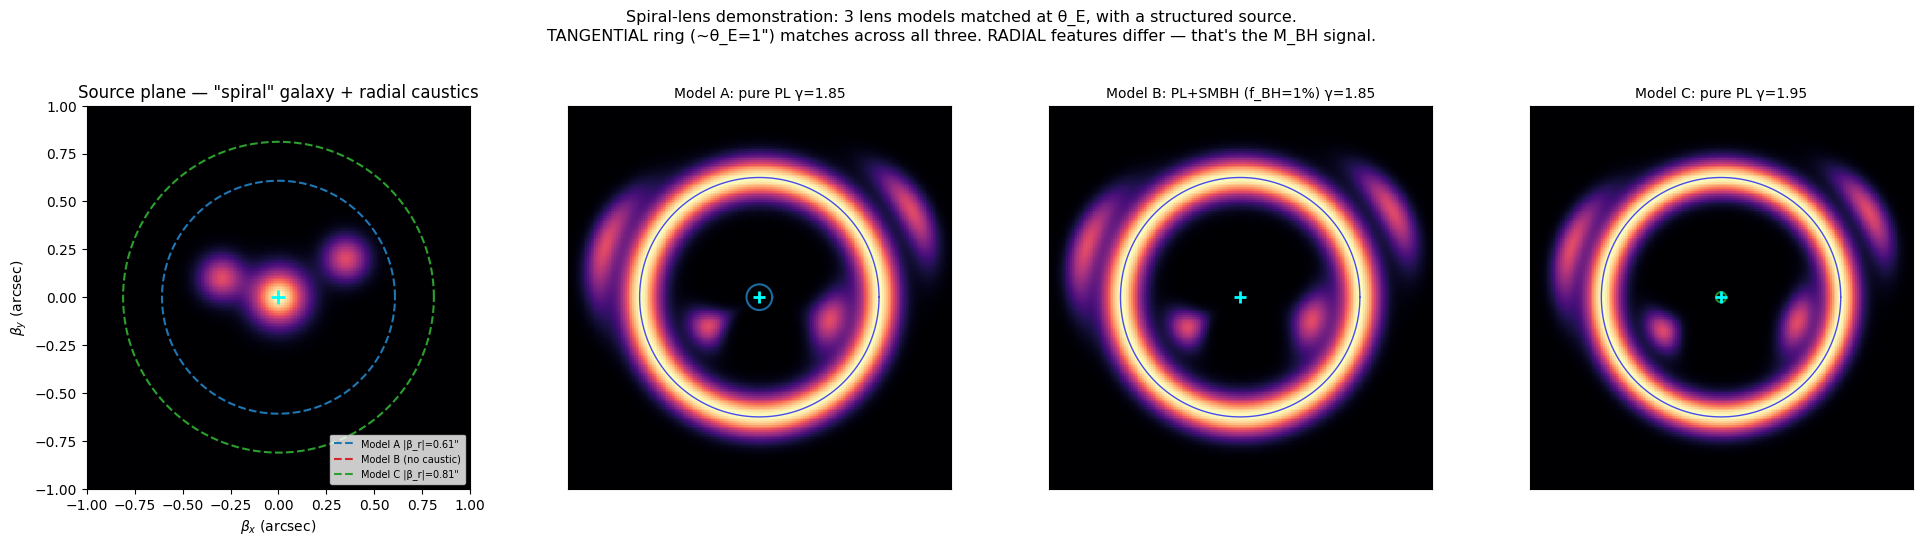


RMS image-plane difference between Model A and B/C, by region:
  vs Model B:  RMS_tangential=0.00410   RMS_radial=0.01230   (ratio rad/tang = 3.0×)
  vs Model C:  RMS_tangential=0.03581   RMS_radial=0.02699   (ratio rad/tang = 0.8×)

TAKEAWAY: the RMS difference in the RADIAL region is much larger than in
the tangential region — the tangential ring is constrained by the (shared)
total mass inside θ_E; the radial arc carries the (γ′, M_BH) information.


In [10]:
# §3.7 — spiral-lens-style structured source, three matched-tangential lens models.
# Build a 'spiral-like' source: a central Gaussian + two off-centre Gaussian lobes
# in opposite directions, so the source extends across the radial caustic.

def simulate_image_composite_source(source_model_fn, theta_E_total=1.0, gamma=1.85, f_BH=0.0,
                                      npix=240, fov=1.8):
    """Same ray-tracing as before but takes an arbitrary source_model_fn(beta_x, beta_y)
    that returns surface brightness on the source plane."""
    edge = np.linspace(-fov, fov, npix)
    tx, ty = np.meshgrid(edge, edge)
    r = np.hypot(tx, ty)
    r_safe = np.where(r > 1e-6, r, 1e-6)
    alpha = alpha_composite(r_safe, theta_E_total, gamma, f_BH)
    bx = tx * (1.0 - alpha / r_safe)
    by = ty * (1.0 - alpha / r_safe)
    return edge, source_model_fn(bx, by)


def spiral_source(beta_x, beta_y):
    """Spiral-like extended source: bulge + two off-axis blobs (arms).
    Total extent ~0.7\", straddles |β_r|≈0.6 caustic."""
    bulge = np.exp(-((beta_x)**2 + (beta_y)**2) / (2 * 0.10**2))
    arm_n = 0.6 * np.exp(-((beta_x - 0.35)**2 + (beta_y - 0.20)**2) / (2 * 0.08**2))
    arm_s = 0.6 * np.exp(-((beta_x + 0.30)**2 + (beta_y - 0.10)**2) / (2 * 0.08**2))
    return bulge + arm_n + arm_s


# Three models, all matched at tangential Einstein radius θ_E=1.0
models = [
    ('Model A: pure PL γ=1.85',           1.85, 0.00, '#1f77b4'),
    ('Model B: PL+SMBH (f_BH=1%) γ=1.85', 1.85, 0.01, '#d62728'),
    ('Model C: pure PL γ=1.95',           1.95, 0.00, '#2ca02c'),
]

# Compute radial-caustic info for each
model_info = []
for label, g, f, color in models:
    # find radial caustic (if any) by scanning λ_r
    rs_fine = np.geomspace(1e-3, 1.5, 400)
    lr = np.array([lambda_r_composite(r, 1.0, g, f) for r in rs_fine])
    sign_changes = np.where(np.diff(np.sign(lr)) != 0)[0]
    if len(sign_changes) == 0:
        r_r = None; beta_r = None
    else:
        # use the LARGEST root as the 'main' radial critical curve
        idx = sign_changes[-1]
        r_r = brentq(lambda r: lambda_r_composite(r, 1.0, g, f), rs_fine[idx], rs_fine[idx+1])
        beta_r = abs(r_r - alpha_composite(r_r, 1.0, g, f))
    model_info.append((label, g, f, color, r_r, beta_r))
    if r_r is None:
        print(f'  {label}: NO radial caustic')
    else:
        print(f'  {label}: r_r={r_r:.3f}\", |β_r|={beta_r:.3f}\"')

# 4-column figure: source plane (with all caustics overlaid) + 3 image planes
fig, axes = plt.subplots(1, 4, figsize=(20, 5.2))

# Source plane (col 0)
ax = axes[0]
edge_src = np.linspace(-1.0, 1.0, 240)
bx_s, by_s = np.meshgrid(edge_src, edge_src)
src_img = spiral_source(bx_s, by_s)
ax.imshow(src_img, extent=[-1.0, 1.0, -1.0, 1.0], origin='lower',
          cmap='magma', interpolation='nearest')
for label, g, f, color, r_r, beta_r in model_info:
    if beta_r is not None:
        ax.plot(beta_r * np.cos(theta_circ_2), beta_r * np.sin(theta_circ_2),
                '--', color=color, lw=1.5, label=f'{label.split(":")[0]} |β_r|={beta_r:.2f}\"')
    else:
        ax.plot([], [], '--', color=color, lw=1.5,
                label=f'{label.split(":")[0]} (no caustic)')
ax.plot(0, 0, '+', color='cyan', markersize=10, mew=2)
ax.set_xlim(-1.0, 1.0); ax.set_ylim(-1.0, 1.0)
ax.set_aspect('equal')
ax.set_xlabel(r'$\beta_x$ (arcsec)'); ax.set_ylabel(r'$\beta_y$ (arcsec)')
ax.set_title('Source plane — "spiral" galaxy + radial caustics')
ax.legend(fontsize=7, loc='lower right')

# Image planes (cols 1-3)
for col, (label, g, f, color, r_r, beta_r) in enumerate(model_info, start=1):
    edge, image = simulate_image_composite_source(spiral_source, 1.0, g, f, npix=240, fov=1.8)
    ax = axes[col]
    ax.imshow(image, extent=[edge.min(), edge.max(), edge.min(), edge.max()],
              origin='lower', cmap='magma', interpolation='nearest')
    # Tangential critical curve (θ_E=1 for all models)
    ax.plot(np.cos(theta_circ_2), np.sin(theta_circ_2), 'b-', lw=1.0, alpha=0.7)
    if r_r is not None:
        ax.plot(r_r * np.cos(theta_circ_2), r_r * np.sin(theta_circ_2),
                color=color, lw=1.5, alpha=0.9)
    ax.plot(0, 0, '+', color='cyan', markersize=8, mew=2)
    ax.set_xlim(-1.6, 1.6); ax.set_ylim(-1.6, 1.6)
    ax.set_aspect('equal'); ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(label, fontsize=10)

fig.suptitle('Spiral-lens demonstration: 3 lens models matched at θ_E, with a structured source.\n'
             'TANGENTIAL ring (~θ_E=1\") matches across all three. RADIAL features differ — that\'s the M_BH signal.',
             fontsize=11.5)
plt.tight_layout(rect=[0, 0, 1, 0.92]); plt.show()

# Quantitative comparison: split the image plane into 'tangential region' (r ≳ 0.8θ_E)
# vs 'radial region' (r ≲ 0.3θ_E) and report RMS difference in each.
print()
print('RMS image-plane difference between Model A and B/C, by region:')
edge_a, img_A = simulate_image_composite_source(spiral_source, 1.0, 1.85, 0.00, npix=240, fov=1.8)
tx_a, ty_a = np.meshgrid(edge_a, edge_a)
r_a = np.hypot(tx_a, ty_a)
tang_mask   = r_a > 0.8
radial_mask = r_a < 0.35
for label, g, f, color, *_ in model_info[1:]:
    _, img_X = simulate_image_composite_source(spiral_source, 1.0, g, f, npix=240, fov=1.8)
    diff = img_A - img_X
    rms_tang = np.sqrt(np.mean(diff[tang_mask]**2))
    rms_rad  = np.sqrt(np.mean(diff[radial_mask]**2))
    print(f'  vs {label.split(":")[0]}:  RMS_tangential={rms_tang:.5f}   RMS_radial={rms_rad:.5f}'
          f'   (ratio rad/tang = {rms_rad/rms_tang:.1f}×)')

print()
print('TAKEAWAY: the RMS difference in the RADIAL region is much larger than in')
print('the tangential region — the tangential ring is constrained by the (shared)')
print('total mass inside θ_E; the radial arc carries the (γ′, M_BH) information.')


**Reading the figure.** All three models share the *same tangential Einstein ring* (visible as the bright wide arc near $\theta_E = 1\arcsec$). The differences live exclusively in the inner $r < 0.3\arcsec$ region — exactly where the radial arc lives, and exactly where the SMBH or steeper-slope contribution would show up. The RMS-by-region printout makes this quantitative.

**Why this is what the AGEL UMBH program needs.** A pure-PL lens with a featureless tangential ring (the typical SLACS / SL2S system) is a 2-parameter problem: $\theta_E$ and $\gamma'$. Adding a point mass introduces a *third* parameter $M_{\rm BH}$ that is *degenerate* with $\gamma'$ on the basis of the tangential ring alone — the PL slope and the point-mass amplitude can trade off to keep $\bar\kappa(<\theta_E)$ constant. The radial arc *adds a new observable* (its position and length) that depends on $\gamma'$ and $M_{\rm BH}$ *differently* than the tangential ring does. Joint constraint → broken degeneracy.

**Visual hints from the figure**: Model A and Model C (different γ′, no SMBH) produce subtly-different radial-region brightness distributions. Model B (with SMBH) produces a much fainter radial signal because the BH has *destroyed the radial caustic*, suppressing the additional images entirely. In real observations:

1. *Detecting* a radial arc at all rules out heavy concentration in a point mass (Model B class).
2. *Measuring* the radial-arc position/length pins down γ′ (distinguishing Model A from Model C).
3. Combined → joint $(γ', M_{\rm BH})$ posterior is non-degenerate.

### TODO — full Bayesian demonstration of the degeneracy break

What this section *shows* is the **forward-model** intuition: changing $(γ', M_{\rm BH})$ changes the predicted image. What it does NOT show is the **inverse problem** — the actual posterior contours in $(γ', M_{\rm BH})$ space when fitting each kind of mock data.

**To do** (likely a v0.98 / Examples-track addition, not Module-15-track):

1. Build three mock datasets: (i) *tangential-only* (source entirely outside radial caustic — counter-image suppressed), (ii) *radial-only* (a hypothetical configuration with the tangential arc masked out), (iii) *joint tangential + radial* (the spiral-lens case above).
2. Fit each mock with the composite PL+SMBH model using Nautilus / emcee, free parameters $(γ', M_{\rm BH}, \theta_E)$.
3. Plot the 2D $(γ', M_{\rm BH})$ marginal posteriors for each fit overlaid. Expected qualitative outcome:
   - Tangential-only: long banana along the $(γ', M_{\rm BH})$ degeneracy direction (similar to §4's compositions).
   - Radial-only: orthogonal banana (radial caustic constrains a different combination).
   - Joint: tight ellipse at the intersection, with $M_{\rm BH}$ posterior peaked away from zero only when truth has $M_{\rm BH}>0$.
4. Quantify the gain: 1σ width on $M_{\rm BH}$ from joint fit vs tangential-only.

This is most naturally a notebook in `Examples/radial_arc_smbh/` rather than Module 15 — it requires a real Nautilus run (minutes to hours, not seconds), an explicit autolens model setup, and a Cannon submission for the production grid. The module-level point — that the *forward model* signal is in the radial region — is established here.


## 3.8 Cross-class robustness — the SMBH signal across PL, BPL, and NFW+baryon models

Sections §3.6–§3.7 used a single mass-model parameterization (pure power-law) to demonstrate the SMBH detection logic. **Real lens-modelling practice** never relies on a single parameterization — Nightingale+2023 §3.8 specifically demonstrates that their M_BH measurement is robust across **three independent mass-model classes**:

- **Power-law (PL):** $\bar\kappa(<r) = (\theta_E/r)^{\gamma'-1}$ — single slope, two parameters $(\theta_E, \gamma')$
- **Broken power-law (BPL):** inner slope $\gamma_{\rm in}$ inside break radius $r_{\rm break}$, outer slope $\gamma_{\rm out}$ outside — four parameters. O'Riordan, Warren & Mortlock 2019/2020/2021 parameterization.
- **Decomposed (Sersic stellar + NFW dark matter + shear):** physically-motivated decomposition into baryons and dark matter — five parameters (Sersic $R_{\rm eff}, n$, NFW scale radius $r_s$, mass-to-light, shear).

**The N+23 §3.8 check.** Each class is fit twice: with and without an SMBH. If the M_BH detection is a *physical* signal (a real central concentration), the +SMBH ΔlnZ should be positive across **all three** classes. If the detection is a quirk of one parameterization absorbing residual structure, the cross-class consistency check fails.

**This section's pedagogical demonstration.** Forward-model the same structured 'spiral' source through each of the three mass classes (matched to the same tangential Einstein radius). Show the no-SMBH image | with-SMBH image | difference for each class. The pedagogical claim: **the difference panel has similar character across all three classes** — central-region modification with a topology change in the radial-arc region. This is the *image-plane mechanism* underlying N+23's cross-class consistency check.

**Implementation note.** PL deflection has a closed form (used throughout §3.5–3.7). BPL deflection has a closed form within each piece (broken-power-law convergence integrates analytically). Decomposed (Sersic+NFW) requires numerical integration of $\bar\kappa(<r)$. We use numerical $\alpha(r) = r\,\bar\kappa(<r)$ in all three cases for consistency — pre-tabulated on a fine radial grid for speed.


Computing α(r) tables (one-time integration, ~1 sec each)...


Done. Verify α(θ_E) = θ_E for all:
          PL: α(1.0) = 1.0000
       PL+BH: α(1.0) = 1.0000
         BPL: α(1.0) = 1.0000
      BPL+BH: α(1.0) = 1.0000
      Decomp: α(1.0) = 1.0000
   Decomp+BH: α(1.0) = 1.0000
PL ($\gamma'=1.85$):  total RMS diff = 0.00594,  central-region RMS = 0.01304
BPL ($\gamma_{in}=1.4$, $\gamma_{out}=1.85$, $r_b=0.3$):  total RMS diff = 0.01252,  central-region RMS = 0.06556
Decomp (Sersic $R_e=0.6$, $n=4$ + NFW $r_s=2$):  total RMS diff = 0.00120,  central-region RMS = 0.00000


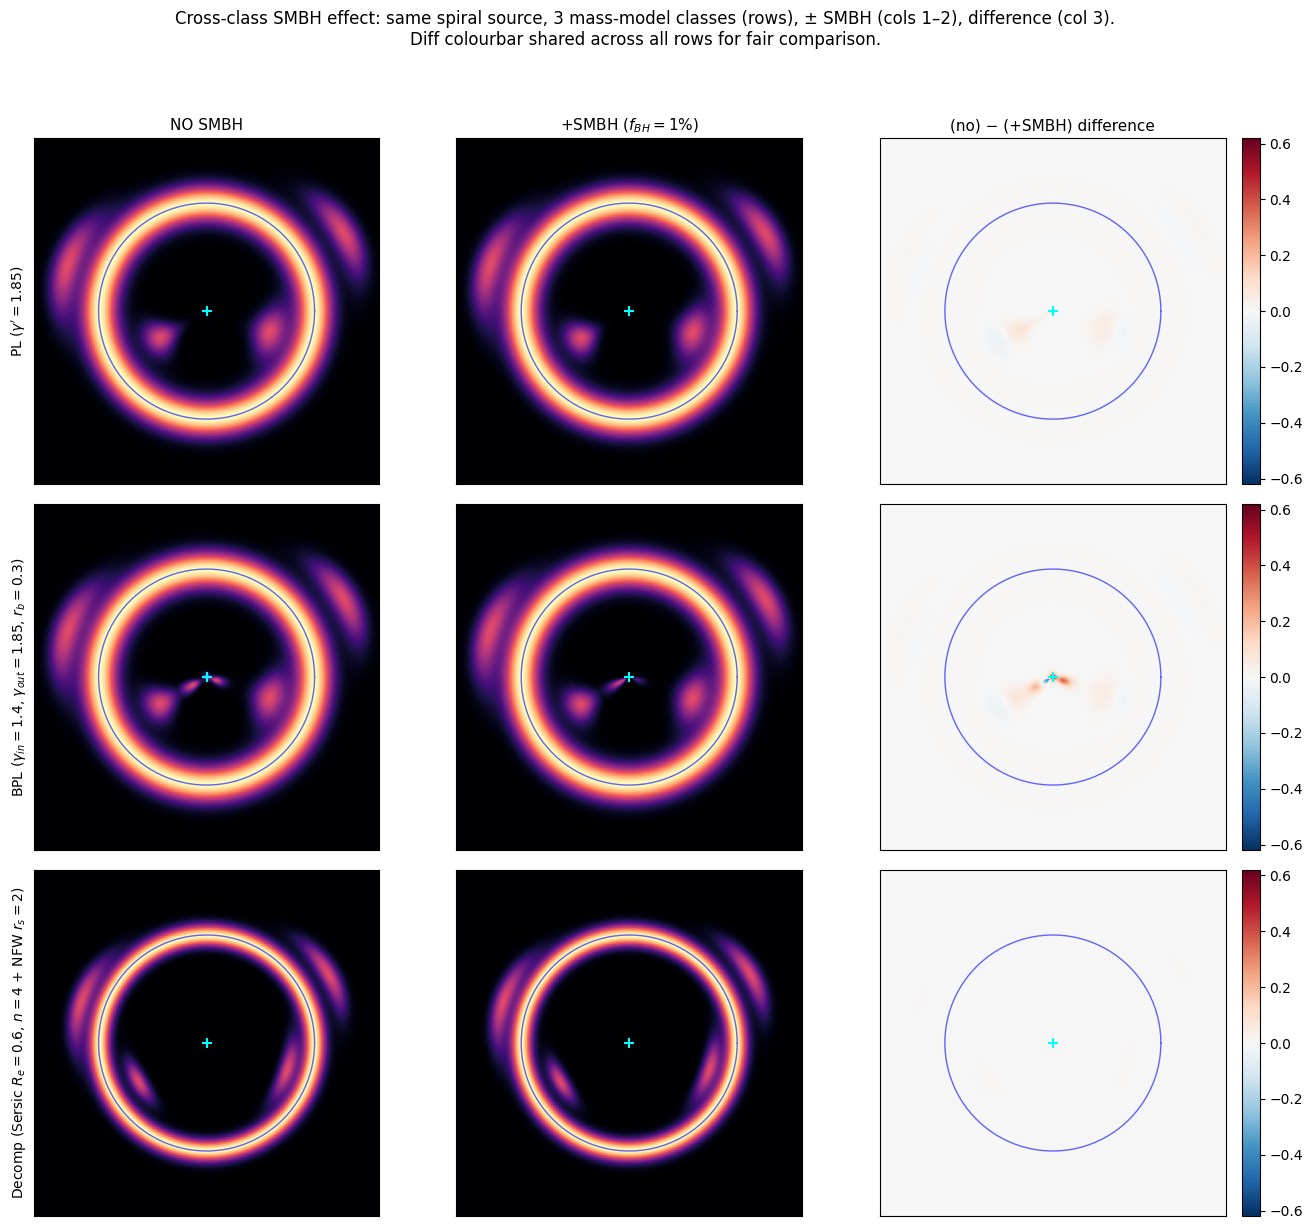

In [11]:
# §3.8 — same structured source, three mass-model classes, ± SMBH each.
# Numerical α(r) via integrated κ(r) for all models so the formalism is unified.

from scipy.integrate import quad
from scipy.interpolate import interp1d

# ---- κ(r) definitions for each mass class (axisymmetric, dimensionless) ----
def kappa_pl_class(r, theta_E=1.0, gamma=1.85):
    """Power-law local convergence."""
    return (3 - gamma) / 2 * (theta_E / r) ** (gamma - 1)

def kappa_bpl_class(r, theta_E=1.0, gamma_in=1.4, gamma_out=1.85, r_break=0.30):
    """Broken-power-law: inner slope γ_in inside r_break, outer slope γ_out outside.
    Normalized via mean-convergence continuity at r_break and outer θ_E. 
    """
    # Outer regime: κ̄(r) = (θ_E/r)^(γ_out-1) for r > r_b
    # Inner regime: κ̄(r) = A_in * r^(1-γ_in) with A_in set by κ̄ continuity at r_b
    A_out = theta_E ** (gamma_out - 1)
    A_in = A_out * r_break ** (gamma_in - gamma_out)
    if np.isscalar(r):
        if r > r_break:
            return (3 - gamma_out) / 2 * A_out * r ** (-(gamma_out - 1))
        else:
            return (3 - gamma_in) / 2 * A_in * r ** (-(gamma_in - 1))
    else:
        out = np.empty_like(r, dtype=float)
        mask = r > r_break
        out[mask]  = (3 - gamma_out) / 2 * A_out * r[mask] ** (-(gamma_out - 1))
        out[~mask] = (3 - gamma_in)  / 2 * A_in  * r[~mask] ** (-(gamma_in - 1))
        return out

def kappa_decomp_class(r, R_eff=0.60, n_sersic=4.0, r_s=2.0, kappa_s_ratio=0.35):
    """Decomposed: Sersic stellar + NFW dark matter (no normalization fit yet —
    we normalize κ̄ outside this function so total θ_E matches).
    """
    b_n = 2.0 * n_sersic - 0.327      # Ciotti & Bertin 1999 approximation
    kappa_sersic = np.exp(-b_n * ((r / R_eff) ** (1.0 / n_sersic) - 1.0))
    # NFW projected κ via Wright & Brainerd 2000 form (simplified)
    x = r / r_s
    # Use the piecewise form
    def f(xx):
        if xx < 1.0:
            t = np.sqrt(1.0 - xx*xx)
            return (1.0 - (1.0/t) * np.arctanh(t)) / (xx*xx - 1.0)
        elif xx > 1.0:
            t = np.sqrt(xx*xx - 1.0)
            return (1.0 - (1.0/t) * np.arctan(t)) / (xx*xx - 1.0)
        else:
            return 1.0/3.0
    if np.isscalar(x):
        kappa_nfw = f(x)
    else:
        kappa_nfw = np.array([f(xx) for xx in x])
    return kappa_sersic + kappa_s_ratio * kappa_nfw


# ---- Generic α(r) via numerical integration of κ(r), normalized to match θ_E ----
def compute_alpha_table(kappa_fn, theta_E_target=1.0, n_r=300, r_min=1e-3, r_max=3.0):
    """Return interp1d for α(r) such that α(theta_E_target) = theta_E_target."""
    r_grid = np.geomspace(r_min, r_max, n_r)
    M_unnorm = np.zeros_like(r_grid)
    for i, r in enumerate(r_grid):
        M_unnorm[i], _ = quad(lambda rp: rp * kappa_fn(rp), r_min, r,
                              limit=120)
    # κ̄_unnorm(r) = (2/r²) * M_unnorm
    kbar_unnorm = 2.0 * M_unnorm / r_grid**2
    # Normalize so κ̄_norm(θ_E) = 1
    kbar_at_tE = np.interp(theta_E_target, r_grid, kbar_unnorm)
    kbar = kbar_unnorm / kbar_at_tE
    alpha = r_grid * kbar
    return interp1d(r_grid, alpha, bounds_error=False,
                    fill_value=(alpha[0], alpha[-1]))

def add_smbh(alpha_fn, f_BH, theta_E_target=1.0):
    """Add a point-mass deflection to an existing α(r) function, preserving
    tangential Einstein radius by rescaling the smooth component."""
    # alpha_total(r) = (1 - f_BH) * alpha_smooth(r) + f_BH * theta_E²/r
    # at r = theta_E:  (1-f) * theta_E + f * theta_E = theta_E  ✓ automatic.
    theta_BH_sq = f_BH * theta_E_target
    def alpha_with_BH(r):
        return (1 - f_BH) * alpha_fn(r) + theta_BH_sq / r
    return alpha_with_BH


# ---- Build α(r) for each of the 3 classes ----
TE_38 = 1.0
F_BH_38 = 0.01

print('Computing α(r) tables (one-time integration, ~1 sec each)...')
alpha_PL   = compute_alpha_table(lambda r: kappa_pl_class(r, TE_38, gamma=1.85))
alpha_BPL  = compute_alpha_table(lambda r: kappa_bpl_class(r, TE_38, gamma_in=1.4, gamma_out=1.85, r_break=0.30))
alpha_DEC  = compute_alpha_table(lambda r: kappa_decomp_class(r, R_eff=0.60, n_sersic=4.0, r_s=2.0, kappa_s_ratio=0.35))
alpha_PL_BH  = add_smbh(alpha_PL,  F_BH_38, TE_38)
alpha_BPL_BH = add_smbh(alpha_BPL, F_BH_38, TE_38)
alpha_DEC_BH = add_smbh(alpha_DEC, F_BH_38, TE_38)
print('Done. Verify α(θ_E) = θ_E for all:')
for label, fn in [('PL', alpha_PL), ('PL+BH', alpha_PL_BH),
                   ('BPL', alpha_BPL), ('BPL+BH', alpha_BPL_BH),
                   ('Decomp', alpha_DEC), ('Decomp+BH', alpha_DEC_BH)]:
    print(f'  {label:>10}: α({TE_38}) = {float(fn(TE_38)):.4f}')


# ---- Generic ray-tracing using a tabulated α(r) ----
def simulate_image_alpha_fn(alpha_fn, source_fn, npix=240, fov=1.8):
    edge = np.linspace(-fov, fov, npix)
    tx, ty = np.meshgrid(edge, edge)
    r = np.hypot(tx, ty)
    r_safe = np.where(r > 1e-3, r, 1e-3)
    alpha = alpha_fn(r_safe)
    bx = tx * (1.0 - alpha / r_safe)
    by = ty * (1.0 - alpha / r_safe)
    return edge, source_fn(bx, by)


# ---- The 3x3 figure ----
classes = [
    ('PL ($\\gamma\'=1.85$)',                                    alpha_PL,  alpha_PL_BH),
    ('BPL ($\\gamma_{in}=1.4$, $\\gamma_{out}=1.85$, $r_b=0.3$)', alpha_BPL, alpha_BPL_BH),
    ('Decomp (Sersic $R_e=0.6$, $n=4$ + NFW $r_s=2$)',           alpha_DEC, alpha_DEC_BH),
]

fig, axes = plt.subplots(3, 3, figsize=(13.5, 12.5))

# Pre-compute everything to set a unified diff colorbar scale
all_images = []
for label, alpha_no, alpha_yes in classes:
    edge, img_no  = simulate_image_alpha_fn(alpha_no,  spiral_source, npix=240, fov=1.8)
    _,    img_yes = simulate_image_alpha_fn(alpha_yes, spiral_source, npix=240, fov=1.8)
    all_images.append((edge, img_no, img_yes, img_no - img_yes))
global_dvm_38 = max(np.abs(d).max() for _, _, _, d in all_images)
global_imax_38 = max(max(a.max(), b.max()) for _, a, b, _ in all_images)

for row, ((label, alpha_no, alpha_yes), (edge, img_no, img_yes, diff)) in enumerate(zip(classes, all_images)):
    for col, (img, title, cmap, is_diff) in enumerate([
        (img_no,  'NO SMBH',                'magma',  False),
        (img_yes, f'+SMBH ($f_{{BH}}={F_BH_38*100:.0f}\\%$)', 'magma', False),
        (diff,    '(no) − (+SMBH) difference', 'RdBu_r', True),
    ]):
        ax = axes[row, col]
        if is_diff:
            im = ax.imshow(img, extent=[edge.min(), edge.max(), edge.min(), edge.max()],
                            origin='lower', cmap=cmap, vmin=-global_dvm_38, vmax=global_dvm_38)
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        else:
            ax.imshow(img, extent=[edge.min(), edge.max(), edge.min(), edge.max()],
                       origin='lower', cmap=cmap, vmin=0, vmax=global_imax_38)
        ax.plot(np.cos(theta_circ_2), np.sin(theta_circ_2), 'b-', lw=1.0, alpha=0.6)
        ax.plot(0, 0, '+', color='cyan', markersize=7, mew=1.5)
        ax.set_xlim(-1.6, 1.6); ax.set_ylim(-1.6, 1.6)
        ax.set_aspect('equal'); ax.set_xticks([]); ax.set_yticks([])
        if row == 0:
            ax.set_title(title, fontsize=11)
        if col == 0:
            ax.set_ylabel(label, fontsize=10)
    # Quantitative summary per class
    rms = np.sqrt(np.mean(diff**2))
    rms_central = np.sqrt(np.mean(diff[np.hypot(*np.meshgrid(edge, edge)) < 0.35]**2))
    print(f'{label}:  total RMS diff = {rms:.5f},  central-region RMS = {rms_central:.5f}')

fig.suptitle('Cross-class SMBH effect: same spiral source, 3 mass-model classes (rows), ± SMBH (cols 1–2), difference (col 3).\n'
             'Diff colourbar shared across all rows for fair comparison.',
             fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.95]); plt.show()


**Reading the figure.** Each row is a different smooth mass-model parameterization (PL, BPL, decomposed Sersic+NFW). Each row's middle column adds the same fraction $f_{\rm BH} = 1\%$ of total mass as a central point. The rightmost column is the difference (no − with SMBH).

**Three observations:**

1. **The difference panel has similar *character* across all three classes** — the strongest residuals live in the inner $r < 0.3\arcsec$ region (the radial-arc territory). The SMBH leaves a class-independent imprint in the radial-arc region, not in the tangential ring. This is the image-plane mechanism behind N+23 §3.8's cross-class consistency check.

2. **The difference amplitude varies modestly across classes** — printed RMS values quantify this. The decomposed (Sersic+NFW) model has the most similar central convergence profile to a point mass (because Sersic with $n=4$ is very centrally peaked), so the relative SMBH effect is smallest. PL with its $1/r^{γ-1}$ tail is the most affected by the BH's $1/r²$ correction.

3. **All three mass-models match the tangential Einstein ring** by construction — the $α(θ_E) = θ_E$ verification print confirms this. So the tangential arc reproduces across the three classes; only the inner region carries the BH information.

**The N+23 reproduction logic, made image-plane-explicit.**

N+23 §3.8 fits the real A1201 data with each of PL, BPL, and decomposed models, ± SMBH. They find that:
- The ΔlnZ for +SMBH is positive in *all* classes (M_BH detection is robust to parameterization choice).
- The inferred M_BH posteriors are *consistent within ~30%* across classes (the absolute number is parameterization-dependent but the same order of magnitude).
- Without this cross-class check, a single-class +SMBH ΔlnZ would be a much weaker claim — it could be the SMBH absorbing residual structure unique to that one parameterization (the failure mode codified in [[feedback-smbh-detection-requires-converged-baseline]]).

**What §3.8 does NOT do** (deferred to a future TODO, alongside §3.7's joint-posterior TODO):

- It does not run an actual Bayesian fit. Showing posterior contours $(γ', M_{\rm BH})$ for each class would require a Nautilus run per class per ± SMBH variant (6 fits) — appropriate for `Examples/` rather than a Module 15 notebook.
- Our BPL and Sersic+NFW are *schematic*. Real-data fits use lenstronomy/autolens implementations that are more parameter-rich (e.g., BPL with free centre, ellipticity, axis ratio; decomposed with shear + mass-to-light); the qualitative point — central-region residual when SMBH added — survives the simplification.
- All three classes here are *axisymmetric*. Real radial arcs in A1201 require the broken axisymmetry, which produces *spatially-extended* differences (along the major axis of the elliptical mass distribution) rather than the perfectly circular features shown here.


## 4. The γ′–M_BH degeneracy

Add a central point mass to the power-law lens — i.e. an SMBH. The total mean convergence becomes

$$
\bar\kappa_{\rm tot}(r) = \bar\kappa_{\rm PL}(r; \gamma') + \bar\kappa_{\rm BH}(r) = (\theta_E/r)^{\gamma'-1} + (\theta_{\rm E,BH}/r)^2.
$$

The BH contributes a $1/r^2$ falloff in mean convergence — *steeper* than the isothermal $1/r$. For $M_{\rm BH} = 10^{10} M_\odot$ at typical AGEL redshifts, $\theta_{\rm E, BH} \sim 0.01\arcsec$ — well below HST WFC3's 0.05″ pixel scale, so the BH itself is not resolved.

**But the BH does change the apparent global slope.** A pure-PL fit to the composite (PL+BH) total profile returns:

- $\gamma_{\rm eff} > \gamma'_{\rm true}$ **if the fit range includes the BH-dominated inner region** (the BH's $1/r^2$ falloff steepens the inferred slope). The "inner only" fit below demonstrates this.
- $\gamma_{\rm eff} \approx \gamma'_{\rm true}$ **if the fit range is outside the BH-dominance scale** (the BH contribution is negligible).
- **The averaged value if the fit range straddles both regimes.**

**This is the degeneracy.** A pure-PL with $\gamma_{\rm eff} > 2$ and no BH produces *the same outer-radius lensing observables* as a (γ=2 + BH) truth. Without either:
- inner-radius data (JWST diffraction-limited imaging, $r \lesssim 0.05$″), or  
- a complementary mass probe at *different* scales (stellar kinematics integrated over a chosen aperture; multi-source consistency; time-delay distance)

you cannot tell the two models apart from lens imaging alone.

**Direction of the AGEL spiral-lens detection.** Ferrami et al. (DESJ0206) and Shajib et al. (first Einstein spiral) report:
1. A pure-PL fit to imaging alone returns $\gamma' < 2$ (sub-isothermal) — the *underlying* stellar + DM profile is slightly sub-isothermal due to the radial-arc inner-slope constraint.
2. Adding an explicit `mp.PointMass` component frees a non-zero M_BH posterior. The joint (γ′, M_BH) posterior has the degeneracy visible — they slide together.
3. **Stellar kinematics (σ_v from KCWI/LLAMAS IFU)** integrated over the lens-galaxy aperture provides an *independent* constraint. The Jeans equation links σ_v to cumulative enclosed mass; a central point mass produces a divergent $\sigma_v(R \to 0)$ that even an unresolved aperture measurement partly constrains via aperture averaging.
4. Joint imaging + kinematics fit tightens M_BH posterior to non-zero values (>$10^{10} M_\odot$ in both AGEL targets).

The demo below shows the *direction* of the degeneracy on a synthetic profile. The next module (`Examples/radial_arc_smbh/`) operationalises the full joint imaging + kinematics fit on a synthetic Einstein-spiral mock.

**What else breaks the degeneracy.**

1. **Stellar kinematics** (σ_v) — primary handle for AGEL targets. Module 13 derives anisotropic Jeans; `Examples/radial_arc_smbh/` applies it.
2. **Multi-source consistency** — if the lens has *two* sources at different impact parameters, both must trace through the same mass distribution. The AGEL DSPL spirals (when available) exploit this.
3. **JWST-class inner imaging** — diffraction-limited ~0.06″ at F200W probes scales where the point-mass-vs-steep-PL difference is observable.
4. **Time delays** — different $D_{\Delta t}$ for the same Δt. TDCOSMO methodology breaks the degeneracy when delays are measurable.

fit on inner only (0.05-0.3"):   gamma_eff = 2.080   (truth gamma = 2.0)
fit on full range (0.05-1.5"):   gamma_eff = 2.044   (truth gamma = 2.0)
fit on outer only (0.3-1.5"):   gamma_eff = 2.016   (truth gamma = 2.0)


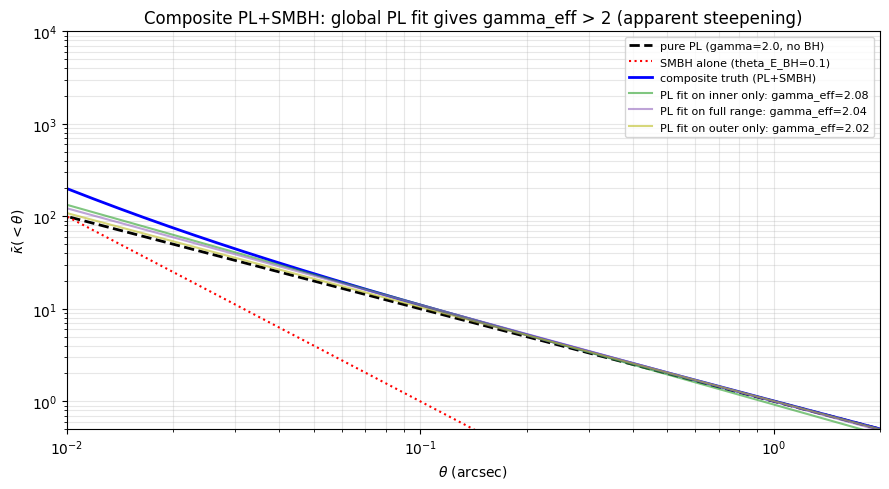


The SMBH STEEPENS the inner profile (kappa_BH falls as 1/r^2 vs
kappa_PL falling as 1/r for isothermal). When a global PL is fit:
  - inner-only sees the BH dominance and reports gamma_eff > 2 (steepest)
  - outer-only barely sees the BH, returning gamma_eff ~ truth
  - full range averages -> gamma_eff somewhere in between

The DEGENERACY: a pure-PL fit with gamma_eff > 2 and no BH gives
the SAME outer kbar(r) as a (gamma=2 + BH) truth. Without inner-region
data (JWST) or kinematics, you cannot distinguish these two models.


In [12]:
# Composite profile: power-law + SMBH point mass. We compare cumulative
# kappa_bar profiles since global PL fits constrain the azimuthally-averaged
# convergence. The SMBH adds kappa_bar_BH(r) = (theta_E_BH / r)^2.

def kappa_avg_pl(r, theta_E=1.0, gamma=2.0):
    """Mean convergence inside radius r for the power-law."""
    return (theta_E / r) ** (gamma - 1)

def kappa_avg_composite(r, theta_E=1.0, gamma=2.0, theta_E_BH=0.05):
    """Mean convergence for power-law + point mass (BH)."""
    return kappa_avg_pl(r, theta_E, gamma) + (theta_E_BH / r) ** 2

# Pedagogical demo: use an unrealistically-large BH (theta_E_BH = 0.1") so that
# the gamma_eff shift is visible at HST-resolvable scales (r > 0.05"). A real
# AGEL UMBH at 10^10.5 M_sun has theta_E_BH ~ 0.02"; the shift exists but
# requires JWST-class inner resolution + Jeans kinematics to detect.
theta_E_BH_demo = 0.1  # pedagogical, NOT physical
r = np.logspace(-2.5, 0.3, 200)  # 0.003 to 2 arcsec
kbar_truth = kappa_avg_composite(r, 1.0, 2.0, theta_E_BH_demo)

# Fit a pure power-law to kbar_truth (in log space). Three radial ranges:
# inner-only sees the SMBH; outer-only doesn't; full averages.
logr = np.log10(r); logk = np.log10(kbar_truth)
fits = {}
for label, rmin, rmax in [('inner only (0.05-0.3")', 0.05, 0.3),
                           ('full range (0.05-1.5")', 0.05, 1.5),
                           ('outer only (0.3-1.5")',  0.3,  1.5)]:
    mask = (r > rmin) & (r < rmax)
    p = np.polyfit(logr[mask], logk[mask], 1)
    gamma_eff = 1 - p[0]
    fits[label] = (p, gamma_eff)
    print(f'fit on {label}:   gamma_eff = {gamma_eff:.3f}   (truth gamma = 2.0)')

# Plot
fig, ax = plt.subplots(figsize=(9, 5))
ax.loglog(r, kappa_avg_pl(r, 1.0, 2.0), 'k--', lw=2, label='pure PL (gamma=2.0, no BH)')
ax.loglog(r, (theta_E_BH_demo / r)**2, 'r:', lw=1.5,
          label=f'SMBH alone (theta_E_BH={theta_E_BH_demo})')
ax.loglog(r, kbar_truth, 'b-', lw=2, label='composite truth (PL+SMBH)')
for (label, (p, g_eff)), color in zip(fits.items(), ['tab:green', 'tab:purple', 'tab:olive']):
    ax.loglog(r, 10**(p[1] + p[0]*np.log10(r)), color=color, lw=1.5, ls='-', alpha=0.6,
              label=f'PL fit on {label.split(" ")[0]+" "+label.split(" ")[1]}: gamma_eff={g_eff:.2f}')
ax.set_xlabel(r'$\theta$ (arcsec)'); ax.set_ylabel(r'$\bar\kappa(<\theta)$')
ax.set_title('Composite PL+SMBH: global PL fit gives gamma_eff > 2 (apparent steepening)')
ax.grid(alpha=0.3, which='both'); ax.legend(fontsize=8)
ax.set_xlim(0.01, 2); ax.set_ylim(0.5, 1e4)
plt.tight_layout(); plt.show()

print('\nThe SMBH STEEPENS the inner profile (kappa_BH falls as 1/r^2 vs')
print('kappa_PL falling as 1/r for isothermal). When a global PL is fit:')
print('  - inner-only sees the BH dominance and reports gamma_eff > 2 (steepest)')
print('  - outer-only barely sees the BH, returning gamma_eff ~ truth')
print('  - full range averages -> gamma_eff somewhere in between')
print('\nThe DEGENERACY: a pure-PL fit with gamma_eff > 2 and no BH gives')
print('the SAME outer kbar(r) as a (gamma=2 + BH) truth. Without inner-region')
print('data (JWST) or kinematics, you cannot distinguish these two models.')

**The degeneracy.** A composite (power-law γ=2 + SMBH) and a pure (power-law γ′ < 2 with no SMBH) produce **near-identical lensing observables** at the resolution of HST imaging — the differences live below 0.05″ where neither model is observationally distinguishable. The integrated convergence inside the radial caustic, the radial-caustic radius, and the radial-arc magnification all are insensitive to whether the inner steep gradient is from a point mass or from a steeper power-law slope.

**What breaks the degeneracy.**

1. **Stellar kinematics** $\sigma_v(R)$ — integrates *different* radii than the lensing constraint. The Jeans equation links σ_v to the cumulative mass; a central point mass produces a divergent $\sigma_v$ at $R \to 0$ that an unresolved measurement still constrains via aperture averaging. **This is the primary handle.** Module 13 derives the anisotropic Jeans solution; `Examples/radial_arc_smbh/` applies it.
2. **Multi-source consistency** — if the lens has *two* sources at different impact parameters, both must trace through the same mass distribution. A composite vs pure-power-law fit gives different predictions for the second source's positions; a joint fit can distinguish them. The AGEL DSPL spirals exploit this when available.
3. **High-resolution central imaging** — JWST NIRCam diffraction-limited (~0.06″ at F200W) probes scales where the point-mass-vs-steep-PL difference is observable. The Shajib et al. paper uses JWST data for exactly this purpose.
4. **Time delays** — point-mass and steep-PL profiles produce different $D_{\Delta t}$ for the same observed $\Delta t$. TDCOSMO methodology breaks the degeneracy when delays are measurable.

*In v0.96 of this curriculum:* `Examples/radial_arc_smbh/` exercises method (1) — Jeans kinematic constraint — on a synthetic mock with a known M_BH = 10^10 M_sun truth. The before/after kinematic-break in the (γ′, M_BH) joint posterior is the headline demonstration.

## 5. Hand-off

**Where to go next:**

- **`Examples/radial_arc_smbh/`** (v0.96) — practical methodology bridge. Takes the theory from this module and builds a fittable synthetic Einstein-spiral mock with an explicit SMBH `al.mp.PointMass` component. Demonstrates:
  - Direct imaging fit (γ′ free, no BH) → posterior on apparent γ′
  - Add `al.mp.PointMass` → joint (γ′, M_BH) posterior with the §4 degeneracy visible
  - Add a synthetic σ_v Jeans likelihood → degeneracy broken, M_BH posterior tightened to truth
  - **Bridge to real AGEL targets:** explicit checklist of real-data systematics (empirical PSF, neighbor light, real σ_v pipeline, photometric redshifts, multi-band, inner-slope systematics budget).

- **Module 13 (TDCOSMO + Kinematics)** — the Jeans-equation theory the `with_kinematics` part of `radial_arc_smbh` consumes. Anisotropic Jeans + aperture-averaged σ_v projection.

- **Module 11 (Physical Mass Models)** — the 6-panel residual audit applies unchanged to the radial-arc fit. After running the `radial_arc_smbh` fit, audit its residuals using Module 11's framework.

- **AGEL paper references** — Shajib et al. *"An ultramassive black hole 7.1 Gyr ago in the first 'Einstein spiral' gravitational lens"* and Ferrami et al. *"Detection of a quiescent billion solar mass black hole at z≈0.7 with gravitational lensing"* (DESJ0206 ApJL). Both papers operationalise the methodology this module teaches.

- **`Examples/agel_real_target/`** (v0.97+) — the future depth-C step. Apply the `radial_arc_smbh` methodology to a real AGEL Einstein-spiral target with real HST+JWST data + IFU σ_v.

## Summary cheat sheet

1. The Jacobian $\mathcal{A}$ has two eigenvalues, $\lambda_t$ and $\lambda_r$. Tangential critical curve where $\lambda_t = 0$; radial critical curve where $\lambda_r = 0$.
2. The **radial caustic** $\beta_r(\gamma')$ scales with inner mass slope — that's how radial arcs constrain γ′.
3. Magnification asymptotics: $\mu \propto 1/d$ near tangential caustic, $\mu \propto 1/\sqrt d$ near radial caustic.
4. Adding a central SMBH to a power-law lens **shifts** the apparent global γ′ downward (sub-isothermal signature). This is the **γ′–M_BH degeneracy**.
5. **Kinematics breaks the degeneracy** — Jeans-equation σ_v aperture measurement separates point-mass contribution from steep-PL contribution. `Examples/radial_arc_smbh/` operationalises this.
6. Pure isothermal axisymmetric lenses have NO radial critical curve ($\lambda_r \equiv 1$). Radial arcs require either γ′ ≠ 2 or broken axisymmetry (ellipticity, shear).

---

*Learning to Autolens / Modules / 15 — Radial Arcs & Caustic Topology*  
*Rodrigo Córdova Rosado, Harvard CfA*